<a href="https://colab.research.google.com/github/sejuti009/Welcome-To-Data-Science-/blob/main/tutorial_weeks05_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP3670 / COMP6670 - Introduction to Machine Learning
# Tutorials Weeks 5 and 6: a complete machine learning pipeline

**The Australian National University, School of Computing. Semester 2, 2026.**

Convener: Dr. Diego Marcondes.

---

For four weeks this course has been about ideas: hypothesis sets, the in-sample
error `Ein`, the out-of-sample error `Eout`, Hoeffding's inequality, the VC
dimension, and a catalogue of models. All of it on paper. In Weeks 5 and 6 tutorials we will see how it applies in practice, on real data, in Python.

## 1. The data: a decade of filling up the tank

Every single time Diego has filled up the tank of one of his cars, since June 2015,
he has collected some data: the date, how far he had driven since the last fill-up and
how many litres went in.

**He has been doing this for more than ten years just so he could have real data to deliver this tutorial to you!**

The log follows seven cars. Here they are.

<table><tr><td align="center" valign="top">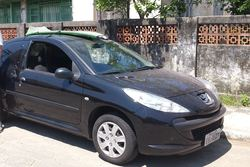<br><b>Peugeot 207</b><br><span style="font-size:90%">small hatchback</span></td><td align="center" valign="top">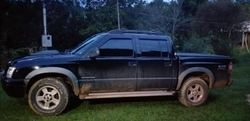<br><b>Chevrolet S10</b><br><span style="font-size:90%">pickup</span></td><td align="center" valign="top">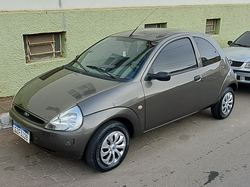<br><b>Ford Ka</b><br><span style="font-size:90%">small hatchback</span></td></tr></table>

<table><tr><td align="center" valign="top">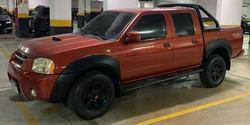<br><b>Nissan Frontier</b><br><span style="font-size:90%">pickup, diesel</span></td><td align="center" valign="top">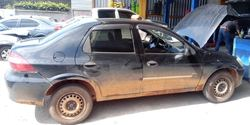<br><b>Chevrolet Prisma</b><br><span style="font-size:90%">small sedan</span></td></tr></table>

<table><tr><td align="center" valign="top">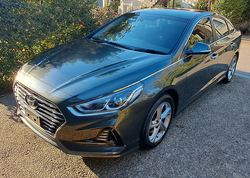<br><b>Hyundai Sonata</b><br><span style="font-size:90%">large sedan</span></td><td align="center" valign="top">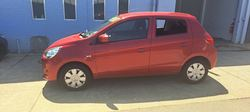<br><b>Mitsubishi Mirage</b><br><span style="font-size:90%">small hatchback</span></td></tr></table>

### What is in the file

The dataset is available **[here](https://www.dropbox.com/scl/fi/xi0uwdi8m7rvduk8zxwbc/vehicle_fuel_log.csv?rlkey=iz294cf1tzgdmmru7o9txxoka&dl=0)**. It comes with a **[README file](https://www.dropbox.com/scl/fi/sf45rfkzj9jayc1l50bqs/README.txt?rlkey=vlfp97on8ieov8oxdedbbmz13&st=y6dpfsu6&dl=0)**,
and reading it is the first thing you should do with any dataset somebody hands
you. Click on the link and see what it tells you. Then click on the dataset link
to see how it is organised.

Each row of the dataset is **one tank of fuel**. The columns are:

| Column | Meaning | Type |
|---|---|---|
| `vehicle` | which of the seven cars | categorical, 7 categories |
| `month` | the month of the fill-up, for example `2022-01` | categorical, ordered |
| `km_on_tank` | kilometres driven on that tank, since the previous fill-up | continuous |
| `litres` | litres of fuel put in | continuous |
| `efficiency` | fuel efficiency of that tank, in km per litre | continuous |
| `driving_condition` | `City`, `Highway` or `Mixed` | categorical, 3 categories, **often missing** |

Three things are worth knowing before you touch the data. This is what Lecture 3
calls **prior information**: everything you know about the problem before you
start fitting anything. It is not a formality. It decides which models are
sensible, which comparisons are fair, and which apparent discoveries are
artefacts.

**First, `efficiency` is not a new measurement.** It is computed:

    efficiency = km_on_tank / litres

Any two of those three columns determine the third. Keep that in mind when you
start choosing which columns to use as features.

**Second, `driving_condition` is missing a lot.** It was only ever written down
for the Sonata, the Mirage, the Prisma and the Frontier. For the Ford Ka, the S10
and the Peugeot 207 it was never recorded at all.

**Third, the cars are not the same kind of machine.** If you know nothing about
cars, this is the background you need, and it is genuine prior information: it
tells you what the data *should* look like before you plot anything.

- **How much fuel a car uses depends mostly on how heavy it is and how big its
  engine is.** A heavy vehicle with a large engine has to burn more fuel to move
  the same distance. So the ordering of these cars by fuel use is largely
  predictable from their size.
- The **Ford Ka**, **Mirage**, **Peugeot 207** and **Prisma** are small, light
  cars with small engines, built for city driving and cheap running. Expect them
  to travel the furthest on a litre.
- The **Sonata** is a large sedan: heavier, bigger engine, more comfortable.
  Expect it to sit somewhere in the middle.
- The **S10** and the **Frontier** are **pickup trucks**: heavy, tall, boxy, with
  large engines built for towing and carrying loads. Expect them to use the most
  fuel. The Frontier runs on **diesel**, which extracts more energy per litre
  than petrol, so a diesel usually travels further on a litre than a petrol
  vehicle of the same size.
- **Driving on the highway uses less fuel per kilometre than driving in the
  city.** In the city you constantly accelerate, brake and idle at lights, and
  every acceleration costs fuel that braking then throws away. On a highway the
  car holds a steady speed and wastes far less.

So before seeing a single number you should already expect: pickups worst, small
cars best, highway better than city for every car. Part of the value of the
descriptive analysis is checking whether the data is consistent with this prior information.

## 2. The tools

Python on its own is a fairly small language. Almost everything useful lives in
**packages** that you load at the start of your program. We need four.

| Package | What it is for | Conventional short name |
|---|---|---|
| `numpy` | arrays of numbers, and fast arithmetic on them | `np` |
| `pandas` | tables of data with named columns | `pd` |
| `matplotlib` | plots | `plt` |
| `scikit-learn` | machine learning models | imported piece by piece |

The line `import numpy as np` means "load the package `numpy`, and from now on let
me write `np` instead of `numpy`".

In [1]:
# This cell makes sure every package the notebook needs is installed, then
# loads them. Run this cell first, every time you open the notebook. It
# should print Packages loaded at the end.

import importlib   # lets us test if a package is installed without loading it
import subprocess  # lets us run a command, here pip install, from inside Python
import sys         # sys.executable is the path to the Python running this notebook

# A dictionary: the name you import -> the name you pip install. Most
# packages use the same name for both, but scikit-learn is the exception:
# you import it as sklearn but you pip install it as scikit-learn.
required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}

# Go through each package one at a time.
for import_name, pip_name in required.items():
    # Try to find the package without fully loading it yet.
    try:
        importlib.import_module(import_name)
    # If it is not installed, Python raises ImportError here.
    except ImportError:
        print("Installing", pip_name, "...")
        # Run: python -m pip install <package>, using the same Python that is
        # running this notebook.
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

# Now that every package is guaranteed to be present, load them as normal.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the plots a sensible size and reasonably readable.
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 11

print("Packages loaded.") #This function prints something in the console


Packages loaded.


### A Python primer

A **variable** is a name for a value. A **list** is an ordered collection written
with square brackets. Counting indices starts at **zero** in Python.

In [2]:
# A variable is just a name attached to a value.
distance = 412.5          # a decimal number, called a "float"
tanks = 7                 # a whole number, called an "int"
name = "Frontier"         # text, called a "string"

print(distance, tanks, name)

# A list holds several values in order. Square brackets.
efficiencies = [10.4, 13.9, 15.2, 11.1]

# Positions count from ZERO. So the first element is at position 0.
print("first  :", efficiencies[0])
print("second :", efficiencies[1])
print("last   :", efficiencies[-1])     # -1 means "last", -2 means "second last"

# A "slice" takes a range of positions. The start is included, the stop is NOT.
print("first two:", efficiencies[0:2])

print("how many :", len(efficiencies)) #Length of a list

412.5 7 Frontier
first  : 10.4
second : 13.9
last   : 11.1
first two: [10.4, 13.9]
how many : 4


In [3]:
# A numpy ARRAY looks like a list, but arithmetic works on the whole thing
# at once. This is the single most important object in numpy.

x = np.array([10.4, 13.9, 15.2, 11.1])

print("the array      :", x)
print("add 1 to all   :", x + 1)          # no loop needed
print("double them all:", x * 2)
print("mean           :", x.mean())
print("std deviation  :", x.std())
print("largest        :", x.max())

# You can compare a whole array to a number. The result is an array of
# True/False, which numpy calls a "mask".
mask = x > 12
print() #Jump a line
print("which are above 12 :", mask)

# And you can use a mask to pull out just those elements. This is how you will
# filter data.
print("the values above 12:", x[mask])
print("how many above 12  :", mask.sum())   # True counts as 1, False as 0

the array      : [10.4 13.9 15.2 11.1]
add 1 to all   : [11.4 14.9 16.2 12.1]
double them all: [20.8 27.8 30.4 22.2]
mean           : 12.65
std deviation  : 1.970406049523803
largest        : 15.2

which are above 12 : [False  True  True False]
the values above 12: [13.9 15.2]
how many above 12  : 2


## 3. Reading the data

The dataset lives online as a `.csv` file, which is the plainest possible way to
store a table: one line per row, values separated by commas. `pandas` reads it in
one line, straight from a web address.

A **DataFrame** is the pandas version of a spreadsheet: a table where every
column has a name and a type. That is what our dataset will be. You pull a single
column out with square brackets and its name, and what comes back behaves very
much like a numpy array.

In [4]:
# The address of the dataset. If you are running this offline, replace the
# address with the path to your local copy, for example "vehicle_fuel_log.csv".

DATA_URL = ("https://www.dropbox.com/scl/fi/xi0uwdi8m7rvduk8zxwbc/"
            "vehicle_fuel_log.csv?rlkey=iz294cf1tzgdmmru7o9txxoka&dl=1")

# read_csv does exactly what it says: it reads a csv file and hands back a
# DataFrame, which is a table with named columns.
data = pd.read_csv(DATA_URL)

# .shape reports (number of rows, number of columns).
print("rows and columns:", data.shape)

rows and columns: (217, 6)


In [5]:
# .head(n) shows the first n rows. Always look at your data before anything else.
data.head(8)

,vehicle,month,km_on_tank,litres,efficiency,driving_condition
0,Peugeot 207,2019-06,178.8,16.840,10.6176,NaN
1,Peugeot 207,2017-04,538.3,40.372,13.3335,NaN
2,Frontier,2023-02,363.3,27.344,13.2863,Highway
3,Frontier,2022-09,312.4,22.952,13.6110,Highway
4,Frontier,2022-12,581.0,49.850,11.6550,Mixed
5,Prisma,2025-01,467.9,29.420,15.9041,Highway
6,Peugeot 207,2016-10,287.2,22.657,12.6760,NaN
7,Frontier,2022-07,213.3,20.537,10.3861,City


In [6]:
# .info() lists the columns, what type each one holds, and how many values are
# actually present. Look at the "non-null" count for driving_condition.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle            217 non-null    object 
 1   month              217 non-null    object 
 2   km_on_tank         217 non-null    float64
 3   litres             217 non-null    float64
 4   efficiency         217 non-null    float64
 5   driving_condition  118 non-null    object 
dtypes: float64(3), object(3)
memory usage: 10.3+ KB


In [7]:
#Pull the vehicle column
data['vehicle']

,vehicle
0,Peugeot 207
1,Peugeot 207
2,Frontier
3,Frontier
4,Frontier
...,...
212,Frontier
213,Peugeot 207
214,Peugeot 207
215,Peugeot 207


> ### Discuss
>
> **Q3.1** The rows are in no particular order, and the exact dates have been
> replaced by the month. Both were done deliberately. What could go wrong if
> the rows had been left in chronological order and you had split off a test
> sample by taking the last 20 percent of the file?

## 4. Before anything else: lock away a test sample

Stop. We have looked at eight rows and the column types, and that is all we are
allowed to see until we have done this.

Remember:

> **The test set may be used exactly once, at the end.**

The error of a hypothesis measured on data that played **no part
whatsoever** in producing that hypothesis is an honest estimate of `Eout`. Plain
Hoeffding applies to it: no VC dimension, no union bound, just the size of the
test sample.

The moment the test data influences anything at all, that guarantee is gone. And
"influences anything" is much broader than one might expect. It includes:

- fitting a model on it, obviously,
- choosing a bandwidth or a polynomial degree by looking at the error on it,
- deciding which features to use after seeing a plot that included it,
- deciding to drop an outlier you noticed in it,
- *looking at a histogram of it and forming an opinion.*

Be aware: **YOU** are part of the learning algorithm. Anything you see, you cannot unsee, and every decision
you make afterwards is contaminated by it.

So we split now, write the test sample to a file, and delete it from memory. We
will not load it again until the very end.

In [8]:
# train_test_split is scikit-learn's tool for splitting a dataset at random.
from sklearn.model_selection import train_test_split

# Two choices worth understanding:
#
# test_size=0.2   hold out 20 percent, which is an 80/20 split for training and test.
#
# random_state=42 fixes the random number generator, so that everybody in the
#                 room gets exactly the same split and can compare numbers. Furthermore,
#                 this makes your experiment reproducible.
#
# stratify=data["vehicle"]
#                 splits each car separately, so that all seven cars appear in
#                 both halves in the same proportions. Without it, the Ford Ka
#                 has only 11 rows in total and could land almost entirely on one
#                 side of the split by bad luck.

train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["vehicle"],
)

print("training rows:", len(train_data))
print("test rows    :", len(test_data))

training rows: 173
test rows    : 44


In [9]:
# Write the test sample to a file, then remove it from memory.
#
# The "del" statement deletes a variable. After this cell, the name test_data
# does not exist any more, and any attempt to use it is an error. That is on
# purpose: it makes peeking take a deliberate act rather than a careless one (oops, saw the test data by mistake).

test_data.to_csv("test_sample.csv", index=False)
print("Test sample written to test_sample.csv and closed.")

del test_data

# From here on, "train_data" is the only data we have. Give it a shorter name.
df = train_data.copy() #df is short for DataFrame
print("Working from now on with", len(df), "rows.")

Test sample written to test_sample.csv and closed.
Working from now on with 173 rows.


> ### Discuss
>
> **Q4.1** We used `stratify` so that every car appears in both halves. Is that
> cheating? We used the `vehicle` column of the test rows to decide the split.
>
> **Q4.2** Our test sample has 44 rows. Lecture 3 gave the error bar for a test
> estimate as depending only on the number of test points. Suppose we had held out
> 50 percent instead of 20 percent. What would we gain, and what would we lose?

## 5. Looking at one variable at a time

Now the part that most people skip and should not: before any model,
find out how the data actually behaves.

We start with the **categorical** variables. For those, "how it behaves" means
counting frequencies.

In [10]:
# value_counts() counts how often each category appears in a column.
print("Fill-ups per car")

# df["vehicle"] pulls out one column; .value_counts() counts each distinct value.
print(df["vehicle"].value_counts())

print()   # print() with nothing inside just leaves a blank line

print("Fill-ups per driving condition")

# dropna=False tells pandas to also COUNT the missing values, instead of
# silently ignoring them.
print(df["driving_condition"].value_counts(dropna=False))

Fill-ups per car
vehicle
Peugeot 207    54
Frontier       43
Prisma         33
Sonata         15
S10            10
Ford Ka         9
Mirage          9
Name: count, dtype: int64

Fill-ups per driving condition
driving_condition
NaN        81
Mixed      35
Highway    29
City       28
Name: count, dtype: int64


Note `dropna=False` in the second count: it makes pandas report the missing
values instead of quietly ignoring them.

Now the **continuous** variables. For those, "how it behaves" means centre, spread
and shape.

In [11]:
# Pick the three numeric columns. Note the DOUBLE square brackets: the inner
# brackets make a list of column names, the outer ones do the selecting.
numeric = df[["km_on_tank", "litres", "efficiency"]]

# .describe() gives the standard summary of every numeric column at once:
# how many values, the mean, the standard deviation, the smallest, the three
# quartiles, and the largest.
# .round(2) cuts the printing down to two decimal places so it is readable.
numeric.describe().round(2)

,km_on_tank,litres,efficiency
count,173.00,173.00,173.00
mean,399.58,32.07,12.87
std,141.89,11.83,3.10
min,82.80,7.18,5.90
25%,307.30,24.24,10.85
50%,390.70,30.19,12.56
75%,461.50,38.57,14.87
max,946.00,71.37,23.98


### The shape of a distribution: histograms

A summary of centre and spread hides the shape. A histogram shows it: chop the
range into bins, count how many observations fall in each.

The number of bins is a choice, and it matters.

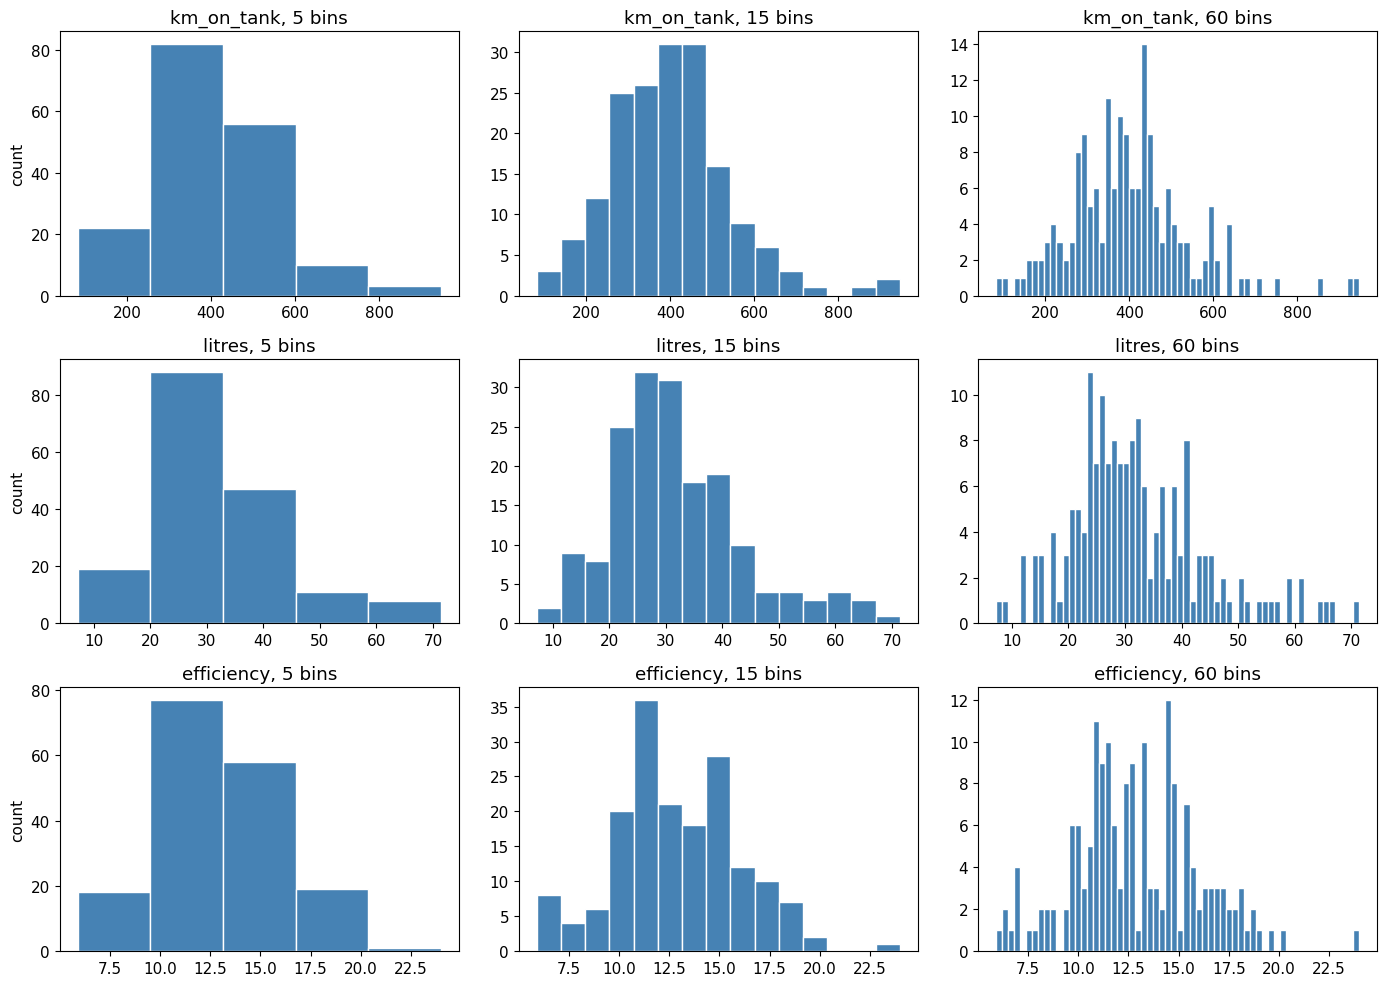

In [12]:
# We want the same picture for all three numeric variables, at three different
# bin counts. That is 3 x 3 = 9 plots, so we build a grid with 3 rows and
# 3 columns and fill it in with two loops.

variables = ["km_on_tank", "litres", "efficiency"]   # one per ROW of the grid
bin_counts = [5, 15, 60]                             # one per COLUMN of the grid

# plt.subplots(rows, columns) creates the grid. It hands back the whole figure
# and an array of "axes", one per small plot. axes[i][j] is row i, column j.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# enumerate() gives us the position AND the value, so row_index counts 0, 1, 2.
for row_index, variable in enumerate(variables):
    for column_index, bins in enumerate(bin_counts):

        # Select the small plot in this row and column.
        ax = axes[row_index][column_index]

        # .hist() draws the histogram: it chops the range of the variable into
        # "bins" equal intervals and counts how many observations land in each.
        ax.hist(df[variable], bins=bins, color="steelblue", edgecolor="white")

        # A title on each small plot so we can tell them apart.
        ax.set_title("%s, %d bins" % (variable, bins))

    # Label the vertical axis once per row, on the leftmost plot only.
    axes[row_index][0].set_ylabel("count")

# tight_layout() stops the titles and labels from overlapping each other.
plt.tight_layout()

# show() actually draws the figure.
plt.show()

Nine pictures, three variables, and the same lesson in every row.

Read across the **efficiency** row first, because it is the clearest.

- With **5 bins** you see a single lump. The picture says "efficiency is somewhere
  between 6 and 24, mostly in the middle", and nothing more. Real structure has
  been averaged away.
- With **60 bins** the picture falls apart into a row of thin spikes with gaps
  between them, most bars holding one or two tanks. The gaps are not real: there
  is no reason a car cannot achieve an efficiency that happens to fall in an empty
  bin. You are looking at the noise of which particular 173 tanks we happened to
  record.
- With **15 bins** you see the useful picture, and the important thing about it is
  that it is **not a single lump**. There is a small group stranded down at the
  bottom, below 8, then a crowded region running from about 10 to 17, and a thin
  tail reaching out to nearly 24.

The other two rows describe the tanks themselves. `km_on_tank` runs from under 100
km to more than 900, with most tanks between 300 and 500. `litres` is visibly
lumpy at 15 bins rather than smooth, which is worth remembering: the cars have
very different tank sizes, so the lumps are the cars showing through.

The number of bins is a **complexity parameter**. Too few and you erase the
structure; too many and you draw the noise.

### Kernel density estimation, and the bandwidth `sigma`

A histogram is jumpy, and it depends on exactly where you put the bin edges.
Lecture 4 introduced the smoother alternative: put a small bump, a **kernel**, on
top of every observation, and add them up. The width of those bumps is the
**bandwidth**, written `sigma`.

`sigma` is the complexity knob:

- **small `sigma`** means narrow bumps, so each observation keeps to itself. The
  estimate is spiky. This is **overfitting**.
- **large `sigma`** means wide bumps that overlap heavily and blur into one another.
  The estimate is a featureless hill. This is **underfitting**.

The next cell has `sigma` at the top. **Run it several times with different
values.** See what happens.

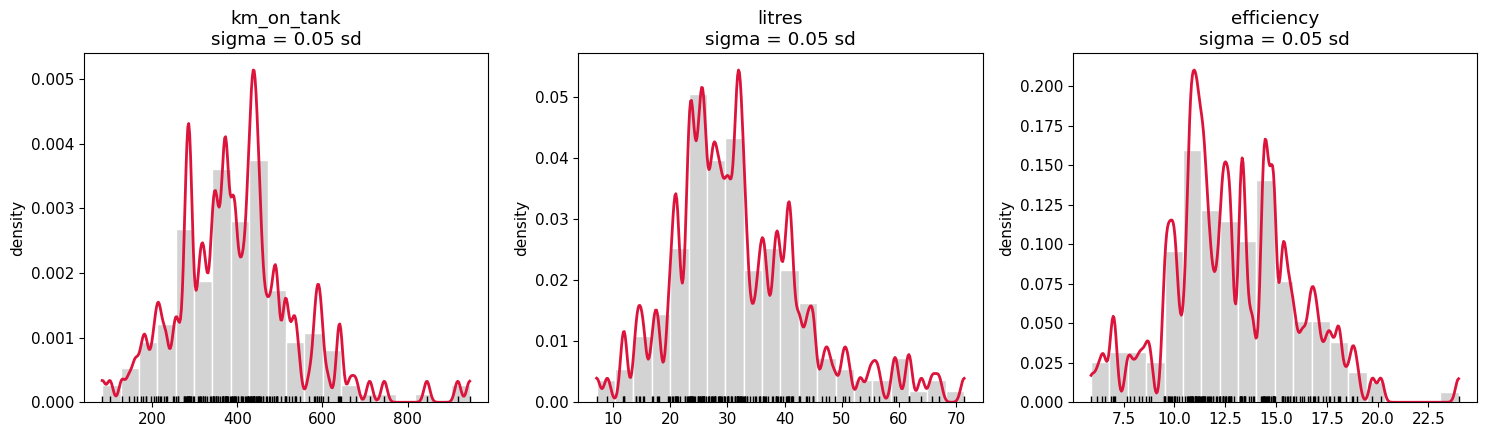

In [13]:
from sklearn.neighbors import KernelDensity

# ---------------------------------------------------------------------------
# CHANGE THIS AND RUN THE CELL AGAIN. Try 0.05, then 0.2, then 0.5, then 1.0.
sigma = 0.05
# ---------------------------------------------------------------------------

# The same three variables as before, one plot each, side by side.
variables = ["km_on_tank", "litres", "efficiency"]

# A grid with 1 row and 3 columns.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, variable in zip(axes, variables):

    # .values turns the pandas column into a plain numpy array.
    values = df[variable].values

    # Each variable lives on a completely different scale: kilometres run into
    # the hundreds, efficiency is around 10. A bandwidth of 0.5 means something
    # quite different for each. So we measure sigma in STANDARD DEVIATIONS of
    # the variable, which makes one setting of sigma comparable across the three.
    bandwidth = sigma * values.std()

    # KernelDensity wants the data as a column, not a row, hence the reshape.
    # reshape(-1, 1) means "one column, work out the number of rows yourself".
    column = values.reshape(-1, 1)

    # Build the estimator. kernel="gaussian" puts a normal-shaped bump on every
    # observation, and bandwidth is how wide each bump is.
    kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian")

    # .fit() hands the data to the estimator.
    kde.fit(column)

    # To draw a curve we need to evaluate the estimate at many points.
    # np.linspace(a, b, n) makes n equally spaced numbers from a to b.
    grid = np.linspace(values.min(), values.max(), 400).reshape(-1, 1)

    # score_samples returns the LOGARITHM of the density, so np.exp undoes that.
    density = np.exp(kde.score_samples(grid))

    # The histogram underneath, for comparison. density=True rescales it so its
    # total area is 1, which puts it on the same footing as the curve.
    ax.hist(values, bins=20, density=True, color="lightgrey", edgecolor="white")

    # The kernel density estimate on top.
    ax.plot(grid, density, color="crimson", linewidth=2)

    # A short vertical tick for every actual observation, along the bottom.
    # np.full_like(values, 0) makes an array of zeros the same length as values.
    ax.plot(values, np.full_like(values, 0), "|", color="black", markersize=8)

    ax.set_title("%s\nsigma = %.2f sd" % (variable, sigma))
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()

> ### Discuss
>
> **Q5.1** Run the cell above with `sigma = 0.2` and with `sigma = 1.0`. Describe
> what each picture claims about the efficiency variable. Which claim is obviously
> wrong, and how do you know it is wrong?
>
> **Q5.2** At a good `sigma` the efficiency density is **not** a single hump. How
> many humps do you see? Before scrolling on: what do you think they are?
>
> **Q5.3** We chose `sigma` by looking at the pictures and
> picking the one that looked right. In Lecture 3 you were warned against choosing
> a model by looking at `Ein`. Is eyeballing the bandwidth the same mistake? If you
> wanted to choose `sigma` honestly, what would you need?

## 6. How features behave inside each group

The overall distribution of `efficiency` had more than one hump. That is a signal
that the data is really several different populations stacked on top of each
other, and it is a very good reason to look at the features **separately within
each car** rather than all lumped together.

This is what plug-in methods depend on: every plug-in method estimates
the distribution of the features **given the class**, and then compares.

In [14]:
# groupby("vehicle") splits the table into one group per car. We then pick the
# efficiency column and ask for several summaries of it at once with .agg().

summary = df.groupby("vehicle")["efficiency"].agg(
    ["count", "mean", "std", "min", "max"]
).sort_values("mean").round(2)      # sort_values puts the thirstiest car first

summary

,count,mean,std,min,max
vehicle,,,,,
S10,10,6.95,0.78,5.90,8.59
Ford Ka,9,10.31,0.85,9.48,11.73
Frontier,43,11.29,1.28,7.67,13.68
Sonata,15,13.23,2.18,9.89,15.60
Peugeot 207,54,13.51,3.10,8.04,23.98
Mirage,9,14.48,0.52,13.47,14.97
Prisma,33,15.76,2.21,10.90,19.74


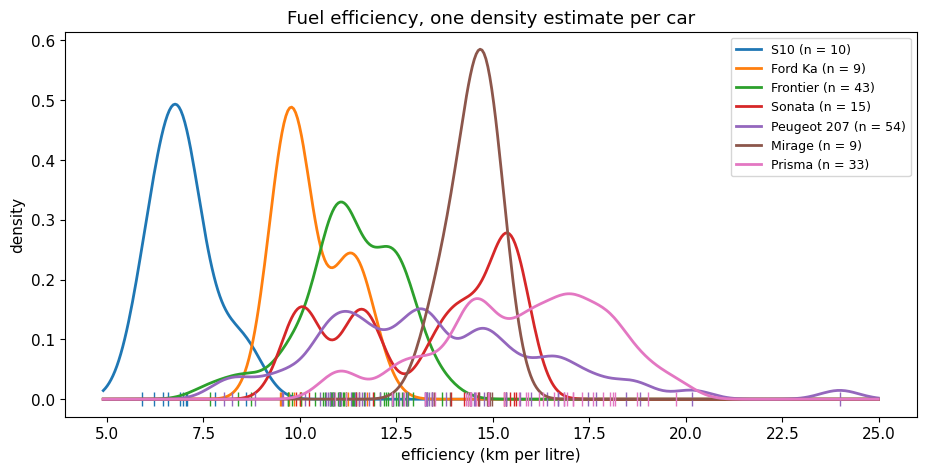

In [15]:
# One density estimate per car, all drawn on the same axes so they can be
# compared. This replaces the summary table above with a picture.

# A fixed bandwidth in km per litre. Try changing it.
sigma = 0.5

# A grid of efficiency values to evaluate every curve on. We use the same grid
# for all cars so the curves are directly comparable.
grid = np.linspace(df["efficiency"].min() - 1,
                   df["efficiency"].max() + 1, 400).reshape(-1, 1)

# Order the cars by their average efficiency, so the legend reads in a sensible
# order rather than alphabetically.
order = df.groupby("vehicle")["efficiency"].mean().sort_values().index

plt.figure(figsize=(11, 5))

for car in order:

    # Select this car's rows, then its efficiency column, as a numpy array.
    values = df.loc[df["vehicle"] == car, "efficiency"].values

    # Fit the kernel density estimate to this car alone.
    kde = KernelDensity(bandwidth=sigma, kernel="gaussian")
    kde.fit(values.reshape(-1, 1))

    # Evaluate it on the shared grid and undo the logarithm.
    density = np.exp(kde.score_samples(grid))

    # Draw the curve. The label is what appears in the legend.
    line = plt.plot(grid, density, linewidth=2,
                    label="%s (n = %d)" % (car, len(values)))

    # Mark this car's actual observations with ticks, in the same colour as its
    # curve. line[0].get_color() asks the line we just drew what colour it got.
    plt.plot(values, np.full_like(values, 0), "|",
             color=line[0].get_color(), markersize=10)

plt.xlabel("efficiency (km per litre)")
plt.ylabel("density")
plt.title("Fuel efficiency, one density estimate per car")
plt.legend(fontsize=9)
plt.show()

Now the same idea for the other grouping we have: the driving condition. Only
four cars ever recorded it, so we look at those.

In [16]:
# .notna() is True wherever a value is present and False where it is missing.
# Using it inside df[...] keeps only the rows where the condition was recorded.
labelled = df[df["driving_condition"].notna()]

print("rows with a driving condition:", len(labelled))
print()

# Group those rows by driving condition and summarise the efficiency in each.
print(labelled.groupby("driving_condition")["efficiency"]
      .agg(["count", "mean", "std"]).round(2))

rows with a driving condition: 92

                   count   mean   std
driving_condition                    
City                  28  12.60  2.11
Highway               29  14.10  2.96
Mixed                 35  14.06  2.17


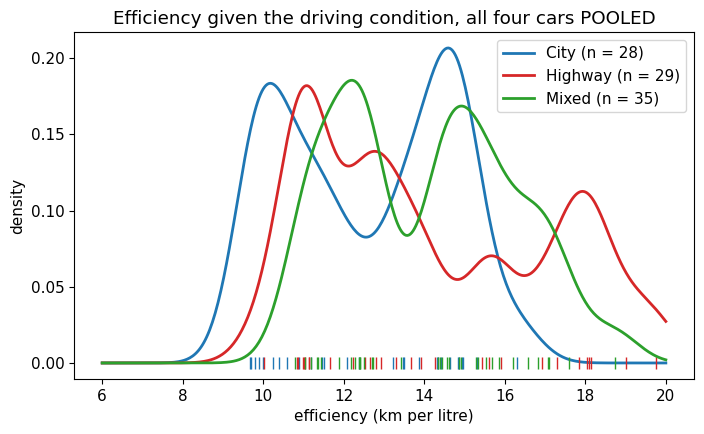

In [17]:
# Densities of efficiency given the driving condition, all cars pooled together.
# This is the picture Lecture 4 draws before building a plug-in rule: the
# distribution of a feature GIVEN the class.

sigma = 0.6

# The grid we evaluate every curve on.
grid = np.linspace(6, 20, 400).reshape(-1, 1)

# A dictionary pairing each condition with the colour we want for it.
colours = {"City": "tab:blue", "Highway": "tab:red", "Mixed": "tab:green"}

# .items() loops over a dictionary giving the key and the value together.
for condition, colour in colours.items():

    # Rows with this condition, efficiency column only.
    subset = labelled.loc[labelled["driving_condition"] == condition,
                          "efficiency"].values

    kde = KernelDensity(bandwidth=sigma, kernel="gaussian")
    kde.fit(subset.reshape(-1, 1))

    plt.plot(grid, np.exp(kde.score_samples(grid)), color=colour, linewidth=2,
             label="%s (n = %d)" % (condition, len(subset)))

    # The observations themselves, as ticks along the bottom.
    plt.plot(subset, np.full_like(subset, 0), "|", color=colour, markersize=8)

plt.xlabel("efficiency (km per litre)")
plt.ylabel("density")
plt.title("Efficiency given the driving condition, all four cars POOLED")
plt.legend()
plt.show()

That picture is disappointing. The three curves sit almost on top of one
another. Pooled across cars, knowing the driving condition tells you remarkably
little about efficiency.

But we already know **(prior information)** these cars are wildly different from each other. So let us
stop pooling them.

In [18]:
# Mean efficiency for every combination of car and driving condition.
# Grouping by TWO columns gives one number per combination; .unstack() then
# turns the second grouping variable into columns, so we get a proper table.

table = (labelled.groupby(["vehicle", "driving_condition"])["efficiency"]
         .mean().unstack().round(2))

print("Mean efficiency (km per litre)")
print(table)
print()

# The same grouping, but .size() counts the rows instead of averaging them.
# Always look at this next to a table of means: a mean of three numbers is
# not worth much.
print("Number of tanks behind each cell")
print(labelled.groupby(["vehicle", "driving_condition"])["efficiency"]
      .size().unstack())

Mean efficiency (km per litre)
driving_condition   City  Highway  Mixed
vehicle                                 
Frontier           10.37    11.80  11.85
Mirage             14.48      NaN    NaN
Prisma             13.39    17.89  15.74
Sonata             10.62    14.80  14.34

Number of tanks behind each cell
driving_condition  City  Highway  Mixed
vehicle                                
Frontier            6.0     16.0   13.0
Mirage              9.0      NaN    NaN
Prisma              8.0      9.0   16.0
Sonata              5.0      4.0    6.0


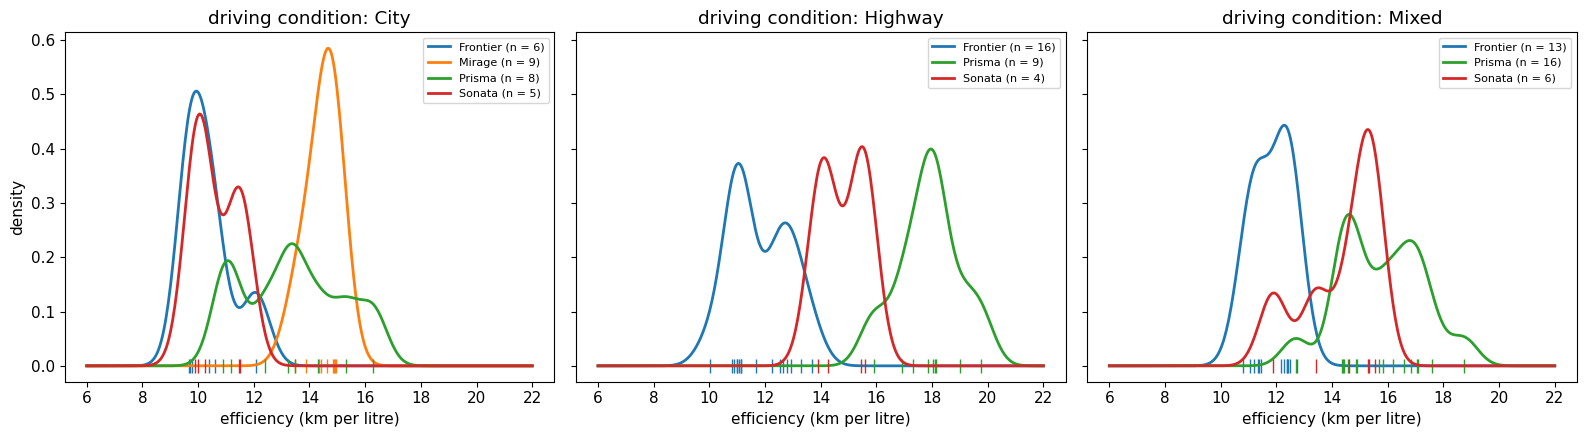

In [19]:
# Now stop pooling the cars. One plot per driving condition, and inside each
# plot one density curve per car.

sigma = 0.5

conditions = ["City", "Highway", "Mixed"]

# Same grid and same colour for a given car in all three plots, so that the eye
# can follow one car across the panels.
grid = np.linspace(6, 22, 400).reshape(-1, 1)
cars_in_order = sorted(labelled["vehicle"].unique())
car_colours = dict(zip(cars_in_order, ["tab:blue", "tab:orange",
                                       "tab:green", "tab:red"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

for ax, condition in zip(axes, conditions):

    for car in cars_in_order:

        # Rows for this car AND this condition. The & means "and"; each
        # condition needs its own brackets.
        subset = labelled.loc[(labelled["vehicle"] == car) &
                              (labelled["driving_condition"] == condition),
                              "efficiency"].values

        # A density estimate needs at least a couple of points to mean anything.
        if len(subset) < 2:
            continue

        kde = KernelDensity(bandwidth=sigma, kernel="gaussian")
        kde.fit(subset.reshape(-1, 1))

        ax.plot(grid, np.exp(kde.score_samples(grid)),
                color=car_colours[car], linewidth=2,
                label="%s (n = %d)" % (car, len(subset)))

        ax.plot(subset, np.full_like(subset, 0), "|",
                color=car_colours[car], markersize=10)

    ax.set_title("driving condition: %s" % condition)
    ax.set_xlabel("efficiency (km per litre)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

Now look across the three panels, following one colour at a time.

Take the Frontier, in blue. In the **City** panel its curve sits around 10. In the
**Mixed** panel it has moved right, to about 12. In the **Highway** panel it is
around 12 as well, and its whole distribution has shifted clear of where it
started. The same happens for the Prisma, in green, which moves from about 14 in
the city to about 18 on the highway. **Within every car, highway driving gets more
kilometres out of a litre**, exactly as the prior information in Section 1 said it
should. In particular, the which car was used is more important than the driving condition, for instance:

> A Frontier driven **entirely on the highway** is less efficient than a Mirage
> driven **entirely in the city**.

This means the effect of *which car* is larger than the effect of *how it
was driven*. So if you only know that a tank achieved 12 km per litre, you cannot
say whether it was a thirsty car on a good run or an economical car on a bad one.

This is also why the pooled picture in the previous plot was so disappointing. The
three pooled curves each mixed several cars together, and the between-car spread
swamped the within-car effect we can now see clearly.

It is, in advance, an argument about modelling. Any model that is going to predict
efficiency well is going to need to know which car (or at least which type of car)
it is looking at.

> ### Discuss
>
> **Q6.1** The pooled density plot said the driving condition barely matters. The
> per-car plots said it matters a lot and in a completely consistent direction.
> Both came from the same rows. Explain how both can be true.
>
> **Q6.2** Suppose you had to predict the efficiency of a tank and you were allowed
> to know **only one** of: the car, or the driving condition. Which do you choose,
> and what in the plots above justifies the choice?
>
> **Q6.3** Go back to the prior information in Section 1. Does the ordering of the curves of the
> cars in these plots match what you expected from their size, weight and fuel?
> Is there anything that surprises you?

## 7. Getting a categorical variable into a model

We have just concluded that any decent model needs to know which car it is looking
at. There is an obstacle: `vehicle` is a word, and every model in Lecture 4 does
arithmetic on numbers.

So we have to turn the words into numbers. The obvious way is also wrong, and it is
worth seeing exactly why.

In [20]:
# THE WRONG WAY. Number the cars 0, 1, 2, ... in whatever order they appear.

# .unique() lists each distinct value once; sorted() puts them in alphabetical
# order and hands back a plain Python list.
cars = sorted(df["vehicle"].unique())

# enumerate(cars) walks the list giving the position and the name together, so
# it produces (0, "Ford Ka"), then (1, "Frontier"), and so on.
#
# The braces build a DICTIONARY, which is a lookup table from a key to a value.
# Read the line as: for each (number, car) pair, store car -> number.
naive_code = {car: number for number, car in enumerate(cars)}

# Loop over the cars and print each one next to the number we just gave it.
# "%-14s -> %d" is a formatting instruction: put a string in a 14-wide
# left-aligned space, then an arrow, then a whole number.
for car in cars:
    print("%-14s -> %d" % (car, naive_code[car]))

Ford Ka        -> 0
Frontier       -> 1
Mirage         -> 2
Peugeot 207    -> 3
Prisma         -> 4
S10            -> 5
Sonata         -> 6


Look at what that code has quietly asserted.

It says Ford Ka is 0, Frontier is 1, Mirage is 2, and so on. Feed that column to a
linear model and the model will use it as a **number**. Which means it believes:

- that Mirage minus Frontier equals Frontier minus Ford Ka, because 2 - 1 = 1 - 0,
- that the Peugeot 207, at 4, is *twice* the Mirage at 2,
- that a car halfway between Frontier and Mirage exists, at 1.5.

None of that means anything. The numbers came from alphabetical order. Sort the
list differently and you get a different model, which is a decisive sign that the
encoding is nonsense.

This is only acceptable when the categories genuinely have an order **and** the
gaps between them are genuinely equal. `month` is ordered, so numbering it is
defensible. `vehicle` is not ordered at all, so numbering it is not.

### A right way: one binary variable per category, minus one

Instead, we make a **separate yes/no column for each category**. Does this row
belong to the Frontier? Yes or no, written 1 or 0. Does it belong to the Mirage?
Yes or no. And so on.

With `k` categories you create `k - 1` such columns, not `k`. One category is left
out and becomes the **reference category**. It is not lost: a row belonging to it
is the row that answers "no" to every single question. Keeping all `k` columns
would make one of them exactly predictable from the others, which breaks the
arithmetic inside a linear model (this makes columns in the model matrix linearly dependent; you will learn this in the linear algebra lectures).

Pandas can create these variables automatically.

In [21]:
# pandas does the whole job in one line. This is called "one-hot encoding",
# or in statistics, "dummy variables".
#
# prefix="is" names the new columns is_Frontier, is_Mirage, and so on.
# drop_first=True leaves out the first category, giving the k-1 columns we want.
# .astype(int) turns True/False into 1/0, which is easier to read.

encoded = pd.get_dummies(df["vehicle"], prefix="is", drop_first=True).astype(int)

# .nunique() counts how many distinct values a column has.
print("original column had %d categories" % df["vehicle"].nunique())

# .shape is (rows, columns), so .shape[1] is the number of columns.
print("encoding produced  %d columns" % encoded.shape[1])
print()
print("the reference category is the one with no column of its own:", cars[0])
print()

encoded.head(8)

original column had 7 categories
encoding produced  6 columns

the reference category is the one with no column of its own: Ford Ka



,is_Frontier,is_Mirage,is_Peugeot 207,is_Prisma,is_S10,is_Sonata
130,0,0,0,0,0,0
65,0,0,0,0,1,0
140,0,0,1,0,0,0
156,1,0,0,0,0,0
132,0,0,0,0,1,0
18,0,0,1,0,0,0
100,0,0,1,0,0,0
125,0,0,1,0,0,0


In [22]:
# Check the claim that the reference category is the all-zeros row.

# This comparison gives a column of True/False, one per row.
is_ford_ka = df["vehicle"] == "Ford Ka"

# .sum() on True/False counts the Trues, because True counts as 1.
print("rows that are a Ford Ka          :", is_ford_ka.sum())

# axis=1 means "add up along each ROW". A row of the encoding sums to zero
# exactly when every one of its yes/no columns says no.
print("rows whose encoding is all zeros :", (encoded.sum(axis=1) == 0).sum())

rows that are a Ford Ka          : 9
rows whose encoding is all zeros : 9


## 8. The S10 mystery (OPTIONAL)

Time for some detective work. This is a real question with a real answer, and
everything you need is in the plots you have already made.

Here is the observation. Of the seven cars in this log, one appears for a short time and is then replaced. Your job is to work out why it left.

In [23]:
# For each car: how many tanks, its mean efficiency, its typical tank size,
# and the first and last month it appears in.
#
# .agg() with named arguments lets us build several summaries at once and
# choose the name of each resulting column. Each one reads as
#     new_column_name = (column_to_summarise, how_to_summarise_it)

story = df.groupby("vehicle").agg(
    tanks=("efficiency", "size"),              # "size" just counts the rows
    mean_efficiency=("efficiency", "mean"),
    mean_litres=("litres", "mean"),
    first_seen=("month", "min"),               # earliest month, as text
    last_seen=("month", "max"),                # latest month
).sort_values("mean_efficiency").round(2)

story

,tanks,mean_efficiency,mean_litres,first_seen,last_seen
vehicle,,,,,
S10,10,6.95,53.40,2021-03,2022-01
Ford Ka,9,10.31,28.22,2022-01,2022-09
Frontier,43,11.29,32.40,2022-01,2025-01
Sonata,15,13.23,45.35,2025-04,2025-12
Peugeot 207,54,13.51,29.99,2015-06,2020-12
Mirage,9,14.48,25.59,2025-02,2025-10
Prisma,33,15.76,25.35,2022-11,2025-01


> ### The data tells a story
>
> Work through these in order. Everything you need is in the table above and in
> the plots from Section 6.
>
> **Q8.1** Which car has the worst fuel efficiency, and by how much is it worse
> than the next worst? Is the gap small or large compared to the differences among
> the other cars?
>
> **Q8.2** Look at `mean_litres`. Roughly how many litres does it take to fill this
> car compared with the others? Now combine that with your answer to Q8.1: for a
> given distance driven, how does its fuel bill compare?
>
> **Q8.3** Which cars appear in the log at exactly the moment this one disappears?
> What kind of car are they, and how do their efficiency compare?
>
> **Q8.4** Put it together. Write one sentence explaining why the S10 had to go and what happened.

### The answer

Discuss your conclusion with the tutor and with the people around you **before**
opening this.

<details>
<summary><b>Click here to reveal the answer</b></summary>

<br>

The S10 managed about **7.0 kilometres per litre**. The next worst car in the log,
the Ford Ka, managed 10.3, and the small cars run from 13.5 up to 15.8. It is not
a little worse than the rest; it is in a class of its own, and it is the clump
sitting on its own at the bottom of the efficiency histogram.

It also has the biggest tanks by a long way, around 53 litres against roughly 25
to 30 for the small cars. So every visit to the petrol station was expensive, and
because the car went so few kilometres per litre, those visits came roughly twice
as often per kilometre driven as for a small car.

Now the dates. Read the `first_seen` and `last_seen` columns of the table above.
The S10 runs from 2021-03 to 2022-01, and **two** cars have a `first_seen` of
2022-01, the very month it bows out: the Ford Ka and the Frontier. The Ford Ka is a
small hatchback, so it is not replacing a pickup - you cannot tow a trailer with
it. The **Frontier** is also a pickup, so it does the same job, but it runs on
diesel and manages 11.3 km per litre against the S10's 7.0. That is more than half
as far again on every single litre, for the same work.

So: **the S10 was replaced because it was by a wide margin the most expensive
vehicle in this log to run, and a pickup that did the same job for far less fuel
was available.** Diego could not afford it! It lasted less than a year.

Notice how you reached that conclusion. You grouped, you averaged, you sorted, and
you read two dates off a table. No model was fitted. No parameter was estimated. No
cross validation was performed. A real and fairly consequential decision - sell the
car - is visible in a table of group means and density plots. We do not necessarily need a complex model to get
information from data.

</details>

## 9. Where this is going: the questions we want to answer

We have spent the session describing the data. Before Week 6, let us be precise
about what we actually want to **predict**, and then use everything above to
sketch a plan.

Three questions, all of them supervised learning problems:

| # | Question | Outcome | Kind |
|---|---|---|---|
| 1 | How efficient will this tank be? | `efficiency` | regression |
| 2 | Which car is this tank from? | `vehicle` | classification, 7 classes |
| 3 | Was this tank a highway trip? | `driving_condition` | classification, binary |

> ### Discuss: make a plan before you model
>
> Do not write any code. Use only the tables and plots from Sections 5 to 8, and
> argue from them.
>
> **Q9.1** For each of the three questions, which columns would you use as
> features, and which would you refuse to use? Give a reason from the descriptive
> analysis for every choice. [*Hint*: two of the columns are exactly determined by
> the others. And think about what you would actually know at the moment you want
> to make the prediction.]
>
> **Q9.2** For question 1, Section 6 showed that the car matters more than the
> driving condition. What does that tell you about which features your model must
> have, and what would you expect to happen to its accuracy if you left the car
> out?
>
> **Q9.3** For question 2, look again at the density plots in Section 6 and at the
> table of tank sizes in Section 8. Which cars do you expect a model to confuse
> with each other, and which do you expect it to identify almost perfectly? Write
> your prediction down now, so you can check it next week.
>
> **Q9.4** For question 3, we can only use the four cars that recorded a driving
> condition. But the cars whose labels we would most like to recover are exactly
> the three that never recorded one. Is that a problem? [*Hint*: Lecture 2, on
> where the data comes from.]

## End of the Week 5 Tutorial (Part A)

Recap what has happened:

**We did the honest thing first.** Before looking at anything, we split off a test
sample and closed it. Everything since has been done on 173 rows, and the 44 we
locked away are still untouched. They stay closed until we open them, once, at
the very end of Part B.

**We looked at the data before modelling it.** The distribution of
efficiency has several humps, and that told us the dataset is really seven
populations stacked together. Pooling the cars hid a strong and perfectly
consistent effect of driving condition. The between-car differences are larger
than the within-car ones, so efficiency alone cannot tell you what kind of driving
a tank saw. Every one of those facts is a constraint on what a sensible model can
look like.

**We met the complexity trade-off twice, without fitting a model.** Once in
the number of histogram bins, and once in the kernel bandwidth `sigma`. Too little
smoothing and you are drawing the noise; too much and you erase the signal. That
is the same trade-off Lecture 3 drew as a U-shaped curve, and in Part B we will
finally choose the knob honestly, by cross validation, instead of by eye.

**And we answered a real question with nothing but group means.** The S10 story
came out of a `groupby` and a sort.

So here is the moral, and it is the reason this session comes before the modelling
one:

> **A careful descriptive analysis tells you a great deal, and it tells you before
> you have committed to any model at all. You do not need a complicated method to
> learn something true from data. When you do reach for a model, its job is to
> answer a question the pictures have already made precise, or that is hidden in the data, not to be the first
> place you look.**

Next week we fit the models of Lecture 4 to the three questions of Section
9. We will choose every complexity parameter by cross validation. And right at the
end, once, we will open the test sample.

---

# Week 6 (Part B): fitting the models

> **Before you start, go back to the top of this notebook and run every cell of
> Week 5, in order.** That loads the packages, reads the data, and rebuilds the
> training sample, so nothing below has to be repeated. It also means the test
> sample stays closed, exactly as we left it.

Last week we looked at the data and never fitted anything. We came away with three
facts that will shape everything below:

1. The cars differ from each other far more than driving conditions differ within
   a car. Any model needs to know which car it is looking at.
2. `efficiency` is exactly `km_on_tank / litres`, so those three columns cannot all
   be used as independent inputs.
3. Choosing a smoothing parameter by eye is not honest. We need cross validation.

Today we work through two of the questions from Section 9, and for each one we
choose how complex the model should be by cross validation:

| # | Question | Kind | Rows |
|---|---|---|---|
| 1 | How efficient will this tank be? | regression | 92 |
| 2 | Which car is this tank from? | classification, 7 classes | 173 |

Then, at the very end, once, we open the test sample.

A third question - was this tank a highway trip? - is in the optional
Section 14 at the end.

## 10. Setup

Almost nothing to do here. The data is already loaded, the split is already made,
and `df` already holds the 173 training rows, because you ran the Week 5 cells
before starting. All we need are the extra tools for the models themselves.

In [24]:
# The extra tools for today. numpy, pandas and matplotlib were already loaded
# in Week 5, and the data was read and split there, so none of that is repeated.

# Cross validation, and the tools that build the folds.
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict

# The models themselves.
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Helpers for putting a scaler and a model together into one object.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# df was created in Week 5 and is the ONLY data we may look at. The test sample
# is sitting in test_sample.csv and stays there until Section 12.
print("training rows carried over from Week 5:", len(df))

training rows carried over from Week 5: 173


### 10.1 The regression problem

**The question.** I am about to drive a certain distance, in a certain car, in
certain conditions. How many kilometres per litre should I expect?

That is a genuinely useful thing to know: combined with the distance, it tells you
how much fuel the trip will need and how much it will cost with today's fuel price.

**The outcome** is `efficiency`.

**The features** are `vehicle`, `driving_condition`, and `km_on_tank`.

Two columns are deliberately left out. `litres` is excluded because
`efficiency = km_on_tank / litres`, so knowing both would hand the model the
answer, and in any case you do not know how many litres the tank will take until
after the trip. `month` is excluded because the cars barely overlap in time, so it
is very nearly a second copy of `vehicle`, and we want to predict from what you
know before setting off, not from when it happened.

Because `driving_condition` is a feature, we can only use rows where it was
recorded. Therefore, we consider only four cars in this model.

In [25]:
# Keep the rows where the driving condition was recorded.
reg = df[df["driving_condition"].notna()].reset_index(drop=True)

print("rows available for the regression:", len(reg))
print()
print(reg["vehicle"].value_counts().to_string())
print()
print(reg["driving_condition"].value_counts().to_string())

rows available for the regression: 92

vehicle
Frontier    35
Prisma      33
Sonata      15
Mirage       9

driving_condition
Mixed      35
Highway    29
City       28


In [26]:
# Build the outcome and the features.

# The outcome: the column we are trying to predict, as a plain numpy array.
y_reg = reg["efficiency"].values

# The two categorical variables become yes/no columns, exactly as in Section 7.
vehicle_columns = pd.get_dummies(reg["vehicle"], prefix="is",
                                 drop_first=True).astype(float)
condition_columns = pd.get_dummies(reg["driving_condition"], prefix="is",
                                   drop_first=True).astype(float)

# The one continuous feature, in kilometres, exactly as recorded.
km = reg["km_on_tank"]

# pd.concat glues the two blocks of columns side by side (axis=1 means columns).
base_features = pd.concat([vehicle_columns, condition_columns], axis=1)

print("categorical features produced these columns:")
print(list(base_features.columns))

categorical features produced these columns:
['is_Mirage', 'is_Prisma', 'is_Sonata', 'is_Highway', 'is_Mixed']


In [27]:
# What would we do with no model at all? Predict the average, every time.
# This is the baseline every model has to beat. In Lecture 3 language it is the
# simplest possible hypothesis set: a single constant.

baseline_error = ((y_reg - y_reg.mean()) ** 2).mean()

print("mean efficiency in the training data: %.2f km per litre" % y_reg.mean())
print("baseline squared in-sample error               : %.3f" % baseline_error)
print("so a typical miss is about %.2f km per litre" % np.sqrt(baseline_error))

mean efficiency in the training data: 13.63 km per litre
baseline squared in-sample error               : 6.176
so a typical miss is about 2.49 km per litre


### 10.2 Polynomial regression, and the complexity knob

Lecture 4 introduced linear regression in the general form

    y = theta_0 * phi_0(x) + theta_1 * phi_1(x) + ... + theta_k * phi_k(x)

and made the point that "linear" refers to the **parameters**, not to the
variables. You are free to choose the basis functions `phi_j` to be anything you
like. Choose `phi_j(x) = x^j` and you have **polynomial regression**: a curve, fitted
by exactly the same machinery as a straight line.

The degree of that polynomial is our complexity knob:

- **degree 0** means `km_on_tank` is ignored entirely.
- **degree 1** means efficiency changes linearly with distance.
- **degree 2** allows one bend, degree 3 allows two, and so on.
- **high degree** allows the curve to wiggle through almost anything.

We keep the categorical columns fixed throughout and only turn this one knob.

In [28]:
def build_features(degree): #This is how we define a function in Python
    """
    The categorical columns, plus km_on_tank raised to the powers 1, 2, ..., degree.

    degree=0 gives the categorical columns alone.
    """
    # .copy() makes an independent copy, so that adding columns below does not
    # modify base_features itself.
    features = base_features.copy()

    # range(1, degree + 1) counts 1, 2, ..., degree. If degree is 0 the loop
    # body never runs, which is exactly what we want.
    for power in range(1, degree + 1):
        features["km^%d" % power] = km ** power

    return features


# Have a look at what this produces for a small degree.
build_features(2).head(4).round(3)

,is_Mirage,is_Prisma,is_Sonata,is_Highway,is_Mixed,km^1,km^2
0,0.0,0.0,0.0,1.0,0.0,312.3,97531.29
1,0.0,0.0,0.0,0.0,1.0,283.1,80145.61
2,0.0,0.0,0.0,0.0,0.0,157.1,24680.41
3,0.0,1.0,0.0,0.0,0.0,287.6,82713.76


#### Fitting one model, and why `Ein` cannot choose the degree

Let us fit a single degree and look at the in-sample error.

In [29]:
# LinearRegression finds the parameters that minimise the sum of squared errors
# on the training data. That is exactly empirical risk minimisation with the
# squared loss, from Lecture 2. The library solves it for us; how it does so is
# a question for later in the course.

# Create the (as yet unfitted) model.
model = LinearRegression()

# .fit(features, outcome) does the fitting.
model.fit(build_features(3), y_reg)

# .predict(features) returns the model's prediction for every row.
predictions = model.predict(build_features(3))

# The in-sample error: average of the squared differences between the truth and
# the prediction. ** 2 squares, .mean() averages.
Ein = ((y_reg - predictions) ** 2).mean()

print("degree 3, Ein = %.3f" % Ein)

degree 3, Ein = 1.331


In [30]:
# Now do that for every degree from 0 to 4 and watch Ein.

# list(range(0, 5)) is the list [0, 1, 2, 3, 4].
degrees = list(range(0, 5))

# An empty list we will append to as we go.
Ein_values = []

for degree in degrees:
    features = build_features(degree)

    # Fitting and assigning in one line: .fit() returns the fitted model.
    model = LinearRegression().fit(features, y_reg)

    # .append() adds one item to the end of a list.
    Ein_values.append(((y_reg - model.predict(features)) ** 2).mean())

# zip() walks two lists side by side, giving one item from each.
for degree, error in zip(degrees, Ein_values):
    print("degree %2d   Ein = %.3f" % (degree, error))

degree  0   Ein = 1.585
degree  1   Ein = 1.368
degree  2   Ein = 1.357
degree  3   Ein = 1.331
degree  4   Ein = 1.250


`Ein` never goes up. It cannot: a degree 4 polynomial can do everything a degree
3 polynomial can do and more, so the best degree 4 fit is at least as good on the
training data as the best degree 3 fit.

This is exactly the warning from Lecture 3. **`Ein` is monotonically decreasing in
complexity, so choosing a model by `Ein` always picks the most complex one on
offer.** It is optimistically biased, and it is useless as a selection criterion.

#### Cross validation

So we need an error estimated on data that took no part in the fitting. Lecture 3
gave the recipe: split the training data into `k` folds, hold out each fold in
turn, fit on the rest, and score on the held-out fold. Average the `k` scores to
get `Ecv`.

Every observation is used for training `k - 1` times and for validation exactly
once. We use `k = 5`, one of the two standard choices.

In [31]:
# KFold(5, shuffle=True) sets up the five folds. shuffle=True mixes the rows
# before splitting, and random_state fixes that shuffle so everyone gets the
# same folds.
folds = KFold(n_splits=5, shuffle=True, random_state=1)

# cross_val_score does the whole loop for us: fit on four folds, score on the
# fifth, five times over, and hand back the five scores.
#
# scikit-learn always MAXIMISES its score, so for errors it uses
# "neg_mean_squared_error", which is the error with a minus sign in front. We
# put the minus back to get an error we can read.
scores = cross_val_score(LinearRegression(), build_features(3), y_reg,
                         cv=folds, scoring="neg_mean_squared_error")

# np.round(..., 3) rounds every number in the array to 3 decimal places.
print("the five fold errors:", np.round(-scores, 3))

# .mean() averages the five, which is the definition of Ecv.
print("Ecv, their average  : %.3f" % (-scores.mean()))

the five fold errors: [1.866 1.079 2.331 1.105 1.957]
Ecv, their average  : 1.667


#### Turn the knob yourself

Change `degree` in the next cell and run it several times. Try **0, 1, 2, 3, 4**.

The cell prints `Ein` and `Ecv`, and then draws **one plot per car**. In each
plot you see that car's own tanks, coloured by driving condition, with the model's
fitted curve for each condition drawn through them. That is the honest way to look
at this model: it makes a different prediction for every combination of car and
condition, so plotting them all on one pair of axes would tell you nothing.

Watch two things as you turn the knob: how much the curves bend, and whether the
extra bending is following the points or following the noise.

degree 0
  Ein =    1.585
  Ecv =    1.699      (baseline, predicting the mean: 6.176)


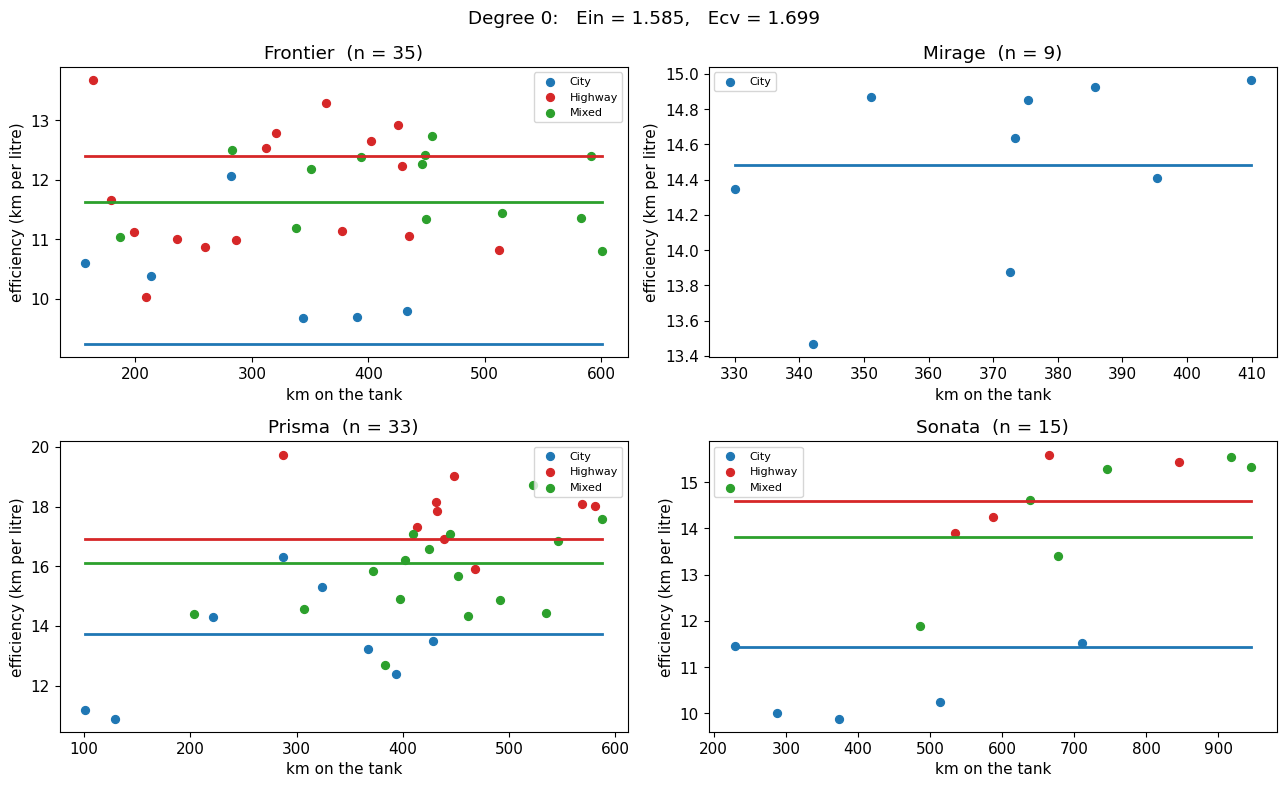

In [32]:
# ---------------------------------------------------------------------------
# CHANGE THIS AND RUN THE CELL AGAIN. Try 0, 1, 2, 3, 4.
degree = 0
# ---------------------------------------------------------------------------

# Build the features at this degree and fit the model.
features = build_features(degree)
fitted = LinearRegression().fit(features, y_reg)

# The two errors.
Ein = ((y_reg - fitted.predict(features)) ** 2).mean()
Ecv = -cross_val_score(LinearRegression(), features, y_reg,
                       cv=folds, scoring="neg_mean_squared_error").mean()

print("degree %d" % degree)
print("  Ein = %8.3f" % Ein)
print("  Ecv = %8.3f      (baseline, predicting the mean: %.3f)"
      % (Ecv, baseline_error))

# ---- one plot per car ------------------------------------------------------

cars_here = sorted(reg["vehicle"].unique())
conditions = ["City", "Highway", "Mixed"]
condition_colours = {"City": "tab:blue", "Highway": "tab:red",
                     "Mixed": "tab:green"}

# A grid with 2 rows and 2 columns, one panel per car.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# .ravel() flattens the 2x2 grid of panels into a straight list of 4.
for ax, car in zip(axes.ravel(), cars_here):

    # This car's rows.
    this_car = reg[reg["vehicle"] == car]

    # A grid of distances covering the range this car was actually driven.
    grid_km = np.linspace(this_car["km_on_tank"].min(),
                          this_car["km_on_tank"].max(), 200)

    for condition in conditions:

        # This car AND this condition.
        points = this_car[this_car["driving_condition"] == condition]

        # Some combinations never happened, for example the Mirage on the
        # highway. Skip them rather than drawing an empty line.
        if len(points) == 0:
            continue

        # The observed tanks.
        ax.scatter(points["km_on_tank"], points["efficiency"], s=32,
                   color=condition_colours[condition], label=condition)

        # To draw the model's curve for THIS car in THIS condition we build a
        # table with the same columns as the training features, set every
        # column to 0, then switch on the two that apply.
        curve = pd.DataFrame(0.0, index=range(len(grid_km)),
                             columns=features.columns)

        # The dummy columns are named is_<car> and is_<condition>. The reference
        # categories have no column, so for them we simply leave the zeros.
        if "is_" + car in curve.columns:
            curve["is_" + car] = 1.0
        if "is_" + condition in curve.columns:
            curve["is_" + condition] = 1.0

        # The polynomial columns, from the grid of distances.
        for power in range(1, degree + 1):
            curve["km^%d" % power] = grid_km ** power

        ax.plot(grid_km, fitted.predict(curve), linewidth=2,
                color=condition_colours[condition])

    ax.set_title("%s  (n = %d)" % (car, len(this_car)))
    ax.set_xlabel("km on the tank")
    ax.set_ylabel("efficiency (km per litre)")
    ax.legend(fontsize=8)

# A single title across the whole figure.
fig.suptitle("Degree %d:   Ein = %.3f,   Ecv = %.3f" % (degree, Ein, Ecv))
plt.tight_layout()
plt.show()

#### The validation curve

Now all the degrees at once.

In [33]:
# Both errors, for every degree.

Ein_values = []
Ecv_values = []

for degree in degrees:
    features = build_features(degree)

    fitted = LinearRegression().fit(features, y_reg)
    Ein_values.append(((y_reg - fitted.predict(features)) ** 2).mean())

    Ecv_values.append(-cross_val_score(LinearRegression(), features, y_reg,
                                       cv=folds,
                                       scoring="neg_mean_squared_error").mean())

print(" degree        Ein           Ecv")
for degree, a, b in zip(degrees, Ein_values, Ecv_values):
    print("   %2d      %8.3f   %10.3f" % (degree, a, b))

# np.argmin returns the POSITION of the smallest value, which we then look up
# in the list of degrees.
best = degrees[int(np.argmin(Ecv_values))]
print()
print("smallest Ecv at degree %d" % best)

 degree        Ein           Ecv
    0         1.585        1.699
    1         1.368        1.505
    2         1.357        1.528
    3         1.331        1.667
    4         1.250        1.585

smallest Ecv at degree 1


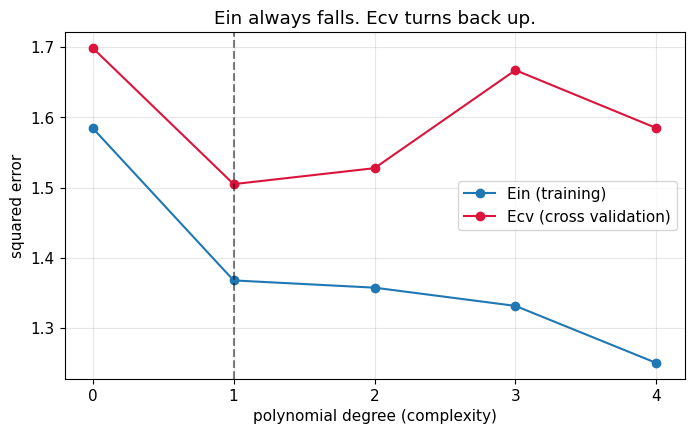

In [34]:
# The same thing as a picture.

plt.plot(degrees, Ein_values, "o-", color="tab:blue", label="Ein (training)")
plt.plot(degrees, Ecv_values, "o-", color="crimson", label="Ecv (cross validation)")

# A horizontal line at the baseline, for reference.
# plt.axhline(baseline_error, color="grey", linestyle=":",
#            label="baseline: predict the mean")

# A vertical line at the chosen degree.
plt.axvline(best, color="black", linestyle="--", alpha=0.5)

plt.xlabel("polynomial degree (complexity)")
plt.ylabel("squared error")

# Only whole-number degrees exist, so label only those.
plt.xticks(degrees)

plt.title("Ein always falls. Ecv turns back up.")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

`Ein` slides downwards the whole way, from 1.585 at
degree 0 to 1.250 at degree 4, and it can do nothing else: a degree 4 polynomial
can do everything a degree 3 polynomial can do and more, so its best fit on the
training data is at least as good.

`Ecv` does not. It drops from 1.699 to **1.505** at degree 1, and from there it
drifts back up, reaching 1.667 at degree 3. The gap between the two curves is
overfitting, and it widens as the degree grows.

Look back at the per-car plots at degree 1 and then at degree 4. At degree 1 each
car gets a straight line. At degree 4 the curves develop bends, and if you follow
the Sonata panel you can watch a bend appear that is clearly chasing two or three
individual tanks rather than describing the car. That bend is what `Ecv` is
punishing.

So the answer is **degree 1**: a straight line in distance. The curvature was never
the useful part. Almost all the predictive power in this problem comes from the
categorical variables, from knowing which car and which driving condition, which
is exactly what the descriptive analysis told us last week.

One more thing to notice in the per-car plots: within each panel the three curves
are **parallel**. That is not something the data decided, it is something we
imposed when we gave each condition its own yes/no column and nothing else. The
model is allowed to shift a car's curve up or down according to the driving
condition, but not to change its shape.

> ### Discuss
>
> **Q10.1** `Ein` at degree 4 is the smallest `Ein` in the table. If you reported
> that number as your model's performance, what precisely would you be claiming,
> and why would it be wrong?
>
> **Q10.2** `Ecv` is not perfectly smooth: it rises to degree 3 and then dips
> slightly at degree 4. Where does that wobble come from?

### 10.3 Two nonparametric models

Polynomial regression assumes a shape and fits its parameters. Lecture 4's
nonparametric methods assume no shape at all. They predict the value at a new point
by **averaging the observed values of nearby points**, and they differ only in how
they decide what "nearby" means and how much each neighbour's vote counts.

Here "nearby" is going to mean something very concrete. To predict a tank we look
only at tanks of the **same car in the same driving condition**, and among those we
look at the ones with a **similar distance driven**. So distance is measured in
plain kilometres, and the categorical variables are not measured at all: they
just decide which tanks are eligible to vote.

Both methods have a complexity knob, and both work **backwards**.

**k nearest neighbours.** Among the eligible tanks, take the `k` whose distance
driven is closest, and average their efficiencies. Small `k` means little
smoothing.

**Kernel regression** (the Nadaraya-Watson estimator). Every eligible tank votes,
but its weight falls away the further its distance is from the one we are
predicting, at a rate set by the bandwidth `sigma`, measured here in kilometres.
Small `sigma` means little smoothing.

For each of them we do the same three things, in the same order as for the
polynomial: write the method out, **turn the knob by hand and look at the fitted
curves car by car**, and only then draw the cross validation curve over all the
settings at once.

In [35]:
def knn_group(train, query, k):
    """
    k nearest neighbours, where the neighbours must be the same car in the same
    driving condition, and distance means difference in km_on_tank.

    train   the tanks we learn from, a DataFrame
    query   the tanks we want predictions for, a DataFrame
    k       how many neighbours to average
    """
    predictions = []

    # range(len(query)) counts 0, 1, ... up to the number of rows to predict.
    for position in range(len(query)):

        # .iloc[position] picks out one row by its position.
        this_tank = query.iloc[position]

        # The eligible tanks: same car AND same condition. The & means "and",
        # and each comparison needs its own brackets.
        eligible = train[(train["vehicle"] == this_tank["vehicle"]) &
                         (train["driving_condition"] == this_tank["driving_condition"])]

        # If we have never seen this combination, fall back on the overall mean.
        if len(eligible) == 0:
            predictions.append(train["efficiency"].mean())
            continue

        # How far each eligible tank is from this one, in kilometres.
        # np.abs makes every difference positive.
        gap = np.abs(eligible["km_on_tank"].values - this_tank["km_on_tank"])

        # np.argsort gives the positions that would sort the array, so the
        # first k of them are the k closest tanks.
        nearest = np.argsort(gap)[:k]

        # Average those neighbours' efficiencies. If there are fewer than k
        # eligible tanks this simply averages all of them.
        predictions.append(eligible["efficiency"].values[nearest].mean())

    # Hand back a numpy array rather than a Python list.
    return np.array(predictions)


# A quick look: predict the first three training tanks using 3 neighbours.
print("actual   :", np.round(reg["efficiency"].values[:3], 2))
print("predicted:", np.round(knn_group(reg, reg.iloc[:3], 3), 2))

actual   : [12.54 12.5  10.6 ]
predicted: [12.11 11.96 11.02]


k = 1
  the five fold errors: [1.467 2.272 2.522 1.235 1.615]
  Ecv =    1.822     (baseline 6.176)


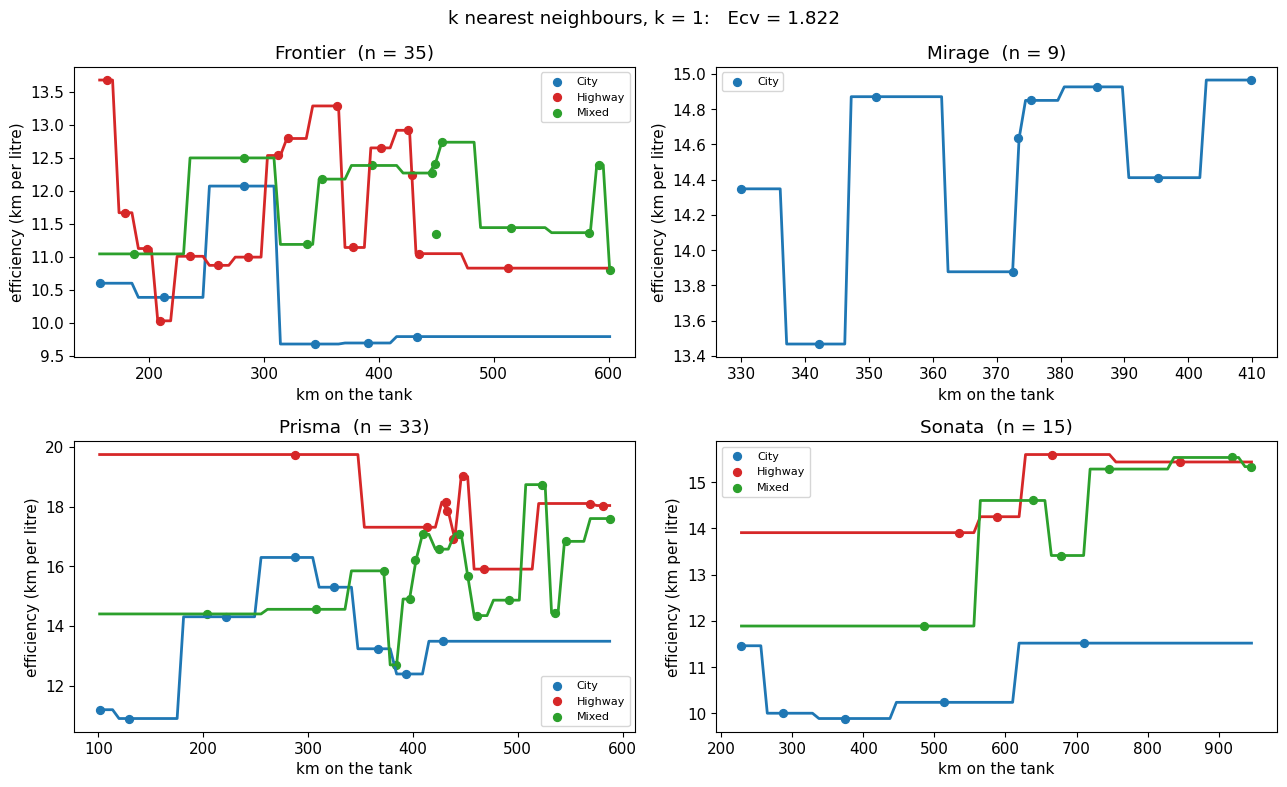

In [36]:
# ---------------------------------------------------------------------------
# CHANGE THIS AND RUN THE CELL AGAIN. Try 1, 2, 3, 5, 10, 25.
k = 1
# ---------------------------------------------------------------------------

# Cross validation written out by hand, so you can see there is no magic in it.
# folds.split(reg) hands back, five times, the row positions to train on and
# the row positions to validate on.
fold_errors = []

for train_rows, validation_rows in folds.split(reg):

    # .iloc[...] selects rows by position.
    predicted = knn_group(reg.iloc[train_rows], reg.iloc[validation_rows], k)

    # The squared error on this fold.
    truth = y_reg[validation_rows]
    fold_errors.append(((truth - predicted) ** 2).mean())

print("k = %d" % k)
print("  the five fold errors:", np.round(fold_errors, 3))
print("  Ecv = %8.3f     (baseline %.3f)"
      % (np.mean(fold_errors), baseline_error))

# ---- what the fitted rule actually looks like, one plot per car ------------

cars_here = sorted(reg["vehicle"].unique())
conditions = ["City", "Highway", "Mixed"]
condition_colours = {"City": "tab:blue", "Highway": "tab:red",
                     "Mixed": "tab:green"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, car in zip(axes.ravel(), cars_here):

    this_car = reg[reg["vehicle"] == car]

    # A grid of distances covering the range this car was actually driven.
    grid_km = np.linspace(this_car["km_on_tank"].min(),
                          this_car["km_on_tank"].max(), 80)

    for condition in conditions:

        points = this_car[this_car["driving_condition"] == condition]

        # Some combinations never happened, for example the Mirage on the
        # highway. Skip them rather than drawing an empty line.
        if len(points) == 0:
            continue

        ax.scatter(points["km_on_tank"], points["efficiency"], s=32,
                   color=condition_colours[condition], label=condition)

        # Ask the rule for a prediction at every distance on the grid, for this
        # car in this condition. We build a small table with the three columns
        # knn_group needs, then hand it over.
        query = pd.DataFrame({"vehicle": car,
                              "driving_condition": condition,
                              "km_on_tank": grid_km})

        ax.plot(grid_km, knn_group(reg, query, k), linewidth=2,
                color=condition_colours[condition])

    ax.set_title("%s  (n = %d)" % (car, len(this_car)))
    ax.set_xlabel("km on the tank")
    ax.set_ylabel("efficiency (km per litre)")
    ax.legend(fontsize=8)

fig.suptitle("k nearest neighbours, k = %d:   Ecv = %.3f"
             % (k, np.mean(fold_errors)))
plt.tight_layout()
plt.show()

k =  1    Ecv = 1.822
k =  2    Ecv = 1.444
k =  3    Ecv = 1.352
k =  4    Ecv = 1.356
k =  5    Ecv = 1.446
k =  7    Ecv = 1.447
k = 10    Ecv = 1.415
k = 15    Ecv = 1.422
k = 25    Ecv = 1.422

smallest Ecv at k = 3


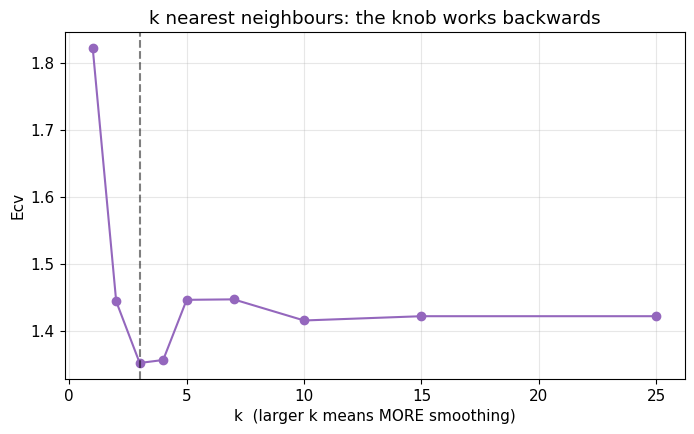

In [37]:
# All the values of k at once.

k_values = [1, 2, 3, 4, 5, 7, 10, 15, 25]
knn_Ecv = []

for k in k_values:
    fold_errors = []
    for train_rows, validation_rows in folds.split(reg):
        predicted = knn_group(reg.iloc[train_rows], reg.iloc[validation_rows], k)
        fold_errors.append(((y_reg[validation_rows] - predicted) ** 2).mean())
    knn_Ecv.append(np.mean(fold_errors))

for k, error in zip(k_values, knn_Ecv):
    print("k = %2d    Ecv = %.3f" % (k, error))

best_k = k_values[int(np.argmin(knn_Ecv))]
print()
print("smallest Ecv at k = %d" % best_k)

plt.plot(k_values, knn_Ecv, "o-", color="tab:purple")
# plt.axhline(baseline_error, color="grey", linestyle=":", label="baseline")
plt.axvline(best_k, color="black", linestyle="--", alpha=0.5)
plt.xlabel("k  (larger k means MORE smoothing)")
plt.ylabel("Ecv")
plt.title("k nearest neighbours: the knob works backwards")
plt.grid(alpha=0.3)
plt.show()

Now kernel regression. Lecture 4 wrote the prediction as a weighted average

    prediction at x  =  sum over i of  W_i(x) * y_i

where the weights `W_i(x)` are never negative and add up to one. For the Gaussian
kernel the weight of a tank falls away with the square of its distance from the
one we are predicting, at a rate set by `sigma`.

Because we are only comparing distances driven, **`sigma` is measured in
kilometres**, and that makes it easy to think about. A `sigma` of 25 km means that
tanks driven within about 25 km of this one count for a lot and tanks driven 200 km
further count for almost nothing. A `sigma` of 2000 km means every tank of that car
in that condition counts roughly equally, and the prediction becomes their plain
average.

In [38]:
def kernel_group(train, query, sigma):
    """
    Nadaraya-Watson kernel regression with a Gaussian kernel, restricted to the
    same car in the same driving condition. sigma is a distance, in kilometres.
    """
    predictions = []

    for position in range(len(query)):

        this_tank = query.iloc[position]

        # The eligible tanks, exactly as before.
        eligible = train[(train["vehicle"] == this_tank["vehicle"]) &
                         (train["driving_condition"] == this_tank["driving_condition"])]

        if len(eligible) == 0:
            predictions.append(train["efficiency"].mean())
            continue

        # The signed difference in distance driven, in kilometres.
        gap = eligible["km_on_tank"].values - this_tank["km_on_tank"]

        # The Gaussian kernel. A tank one sigma away gets about 0.61 of the
        # weight of a tank at zero distance; two sigma away, about 0.14.
        weights = np.exp(-(gap ** 2) / (2 * sigma ** 2))

        # If sigma is so small that every weight underflows to zero, fall back
        # on the plain average of the eligible tanks.
        if weights.sum() == 0:
            predictions.append(eligible["efficiency"].mean())
            continue

        # Dividing by the total makes the weights add up to one, which is what
        # turns this sum into a weighted AVERAGE.
        weights = weights / weights.sum()

        # The prediction: each eligible efficiency, weighted by how near it is.
        predictions.append((weights * eligible["efficiency"].values).sum())

    return np.array(predictions)


print("actual   :", np.round(reg["efficiency"].values[:3], 2))
print("predicted:", np.round(kernel_group(reg, reg.iloc[:3], 50), 2))

actual   : [12.54 12.5  10.6 ]
predicted: [11.96 12.01 10.57]


sigma = 50 km
  the five fold errors: [1.152 1.084 1.62  1.126 1.017]
  Ecv =    1.200     (baseline 6.176)


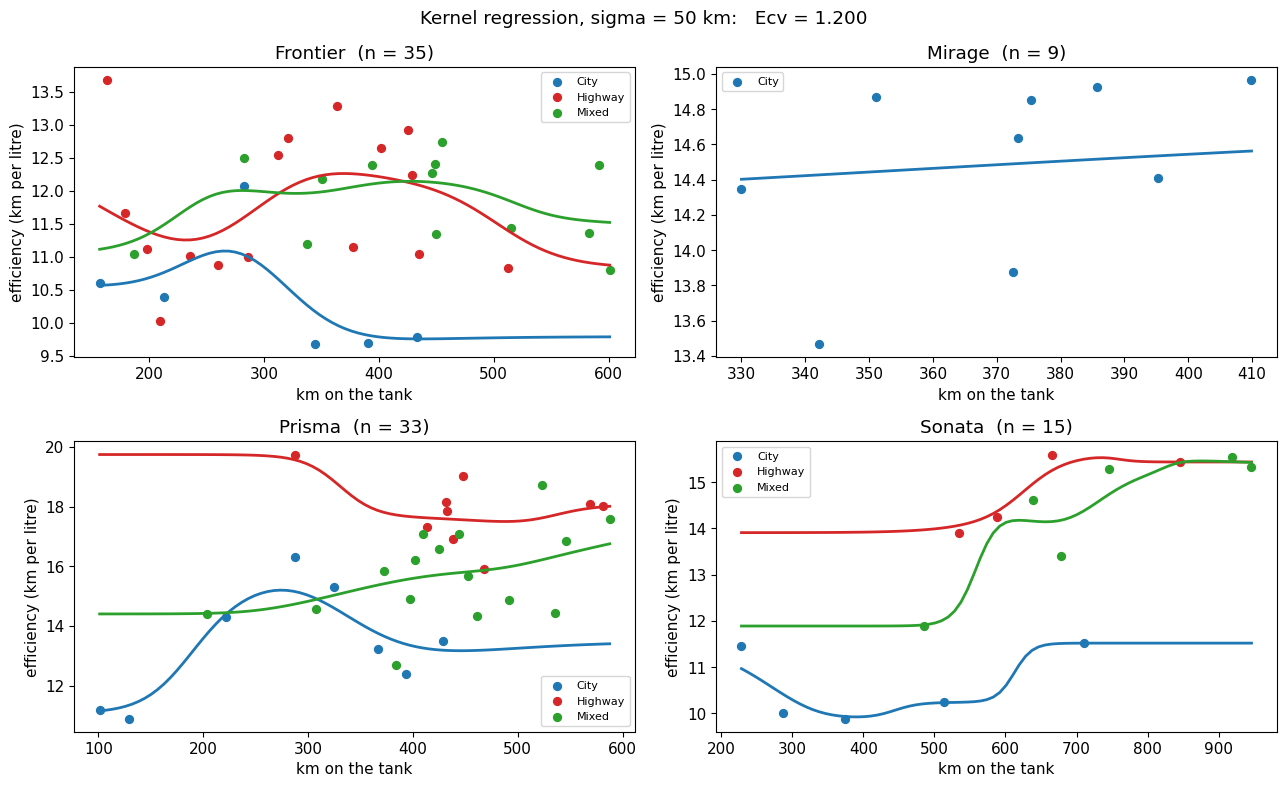

In [39]:
# ---------------------------------------------------------------------------
# CHANGE THIS AND RUN THE CELL AGAIN. sigma is in KILOMETRES.
# Try 5, 25, 50, 200, 2000.
sigma = 50
# ---------------------------------------------------------------------------

fold_errors = []

for train_rows, validation_rows in folds.split(reg):
    predicted = kernel_group(reg.iloc[train_rows], reg.iloc[validation_rows], sigma)
    fold_errors.append(((y_reg[validation_rows] - predicted) ** 2).mean())

print("sigma = %d km" % sigma)
print("  the five fold errors:", np.round(fold_errors, 3))
print("  Ecv = %8.3f     (baseline %.3f)"
      % (np.mean(fold_errors), baseline_error))

# ---- what the fitted rule actually looks like, one plot per car ------------

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, car in zip(axes.ravel(), cars_here):

    this_car = reg[reg["vehicle"] == car]

    grid_km = np.linspace(this_car["km_on_tank"].min(),
                          this_car["km_on_tank"].max(), 80)

    for condition in conditions:

        points = this_car[this_car["driving_condition"] == condition]

        if len(points) == 0:
            continue

        ax.scatter(points["km_on_tank"], points["efficiency"], s=32,
                   color=condition_colours[condition], label=condition)

        query = pd.DataFrame({"vehicle": car,
                              "driving_condition": condition,
                              "km_on_tank": grid_km})

        ax.plot(grid_km, kernel_group(reg, query, sigma), linewidth=2,
                color=condition_colours[condition])

    ax.set_title("%s  (n = %d)" % (car, len(this_car)))
    ax.set_xlabel("km on the tank")
    ax.set_ylabel("efficiency (km per litre)")
    ax.legend(fontsize=8)

fig.suptitle("Kernel regression, sigma = %d km:   Ecv = %.3f"
             % (sigma, np.mean(fold_errors)))
plt.tight_layout()
plt.show()

sigma =     5 km    Ecv = 1.736
sigma =    10 km    Ecv = 1.575
sigma =    25 km    Ecv = 1.291
sigma =    50 km    Ecv = 1.200
sigma =   100 km    Ecv = 1.255
sigma =   200 km    Ecv = 1.346
sigma =   500 km    Ecv = 1.403
sigma =  2000 km    Ecv = 1.420

smallest Ecv at sigma = 50 km


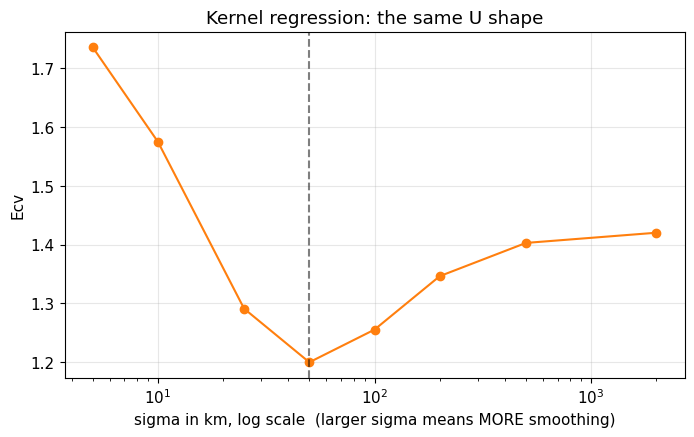

In [40]:
# All the bandwidths at once.

sigma_values = [5, 10, 25, 50, 100, 200, 500, 2000]
kernel_Ecv = []

for sigma in sigma_values:
    fold_errors = []
    for train_rows, validation_rows in folds.split(reg):
        predicted = kernel_group(reg.iloc[train_rows],
                                 reg.iloc[validation_rows], sigma)
        fold_errors.append(((y_reg[validation_rows] - predicted) ** 2).mean())
    kernel_Ecv.append(np.mean(fold_errors))

for sigma, error in zip(sigma_values, kernel_Ecv):
    print("sigma = %5d km    Ecv = %.3f" % (sigma, error))

best_sigma = sigma_values[int(np.argmin(kernel_Ecv))]
print()
print("smallest Ecv at sigma = %d km" % best_sigma)

plt.plot(sigma_values, kernel_Ecv, "o-", color="tab:orange")
# plt.axhline(baseline_error, color="grey", linestyle=":", label="baseline")
plt.axvline(best_sigma, color="black", linestyle="--", alpha=0.5)

# A log scale, because the bandwidths we try span a factor of 400.
plt.xscale("log")
plt.xlabel("sigma in km, log scale  (larger sigma means MORE smoothing)")
plt.ylabel("Ecv")
plt.title("Kernel regression: the same U shape")
plt.grid(alpha=0.3)
plt.show()

> ### Discuss
>
> **Q10.3** Run the kNN cell with `k = 1`. Look at the curves it draws: what is it doing between the points?
>
> **Q10.4** Compare the curves at `k = 1` with those at `k = 25`, and the kernel
> curves at `sigma = 5` km with those at `sigma = 2000` km. Describe in words what
> the rule is doing at each extreme.
>
> **Q10.5** Three methods, three knobs: degree, `k`, `sigma`. For each, say which
> direction is *more* complex. Two of the three run the opposite way from the
> first.

### 10.4 Choose one, and refit on everything

Lecture 3's procedure has four steps. We have done the first three: build
candidates from prior information, estimate `Eout` for each by cross validation,
and select the smallest. Now the fourth:

> **Refit the chosen model on all the available training data.**

The cross-validated scores came from models fitted on four fifths of the training
data. Now that the choice is made, there is no reason to throw away the remaining
fifth. More data gives a better fit of the same model.

In [41]:
# Compare the three families at their best settings.

# The braces build a dictionary: each entry is a name paired with an error.
candidates = {
    "polynomial, degree %d" % best: min(Ecv_values),
    "k nearest neighbours, k = %d" % best_k: min(knn_Ecv),
    "kernel regression, sigma = %d km" % best_sigma: min(kernel_Ecv),
    "baseline: predict the mean": baseline_error,
}

# .items() gives name and error together; sorted(..., key=...) orders them by
# the error, so the best model prints first.
for name, error in sorted(candidates.items(), key=lambda pair: pair[1]):
    print("%-34s Ecv = %7.3f    typical miss %.2f km per litre"
          % (name, error, np.sqrt(error)))

kernel regression, sigma = 50 km   Ecv =   1.200    typical miss 1.10 km per litre
k nearest neighbours, k = 3        Ecv =   1.352    typical miss 1.16 km per litre
polynomial, degree 1               Ecv =   1.505    typical miss 1.23 km per litre
baseline: predict the mean         Ecv =   6.176    typical miss 2.49 km per litre


In [42]:
# Refit the chosen models on the whole training sample, ready for Section 12.
# NOTHING here looks at the test sample.

# The polynomial is a fitted object, so we refit it at the chosen degree.
final_poly = LinearRegression().fit(build_features(best), y_reg)

# The two nonparametric methods have nothing to fit: they keep the training
# data and use it at prediction time. So all we have to remember is the data
# itself, together with the chosen k and sigma.
final_training_data = reg

print("Three models chosen and refitted on all %d training rows." % len(reg))
print("  polynomial degree      :", best)
print("  k for nearest neighbour:", best_k)
print("  sigma for the kernel   : %d km" % best_sigma)

Three models chosen and refitted on all 92 training rows.
  polynomial degree      : 1
  k for nearest neighbour: 3
  sigma for the kernel   : 50 km


## 11. Which car is this tank from?

A different question, and a classification one.

**The question.** Given only how much fuel went in and how far it went, can you
tell which of the seven cars it was?

**The outcome** is `vehicle`, with seven classes. **The features** are `litres` and
`efficiency`. Two features, so we can draw everything.

All 173 training rows are available here, since neither feature has missing
values.

In [43]:
X_class = df[["litres", "efficiency"]].values
y_class = df["vehicle"].values

print("rows:", len(y_class))
print()
print(pd.Series(y_class).value_counts().to_string())

# The baseline for a classifier: always guess the commonest class.
majority = pd.Series(y_class).value_counts(normalize=True).max()
print()
print("always guessing the commonest car would be right %.1f%% of the time"
      % (100 * majority))

rows: 173

Peugeot 207    54
Frontier       43
Prisma         33
Sonata         15
S10            10
Ford Ka         9
Mirage          9

always guessing the commonest car would be right 31.2% of the time


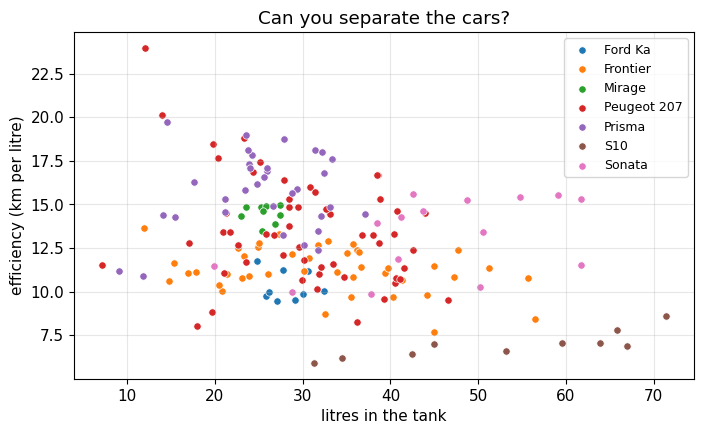

In [44]:
# The picture. Every tank, coloured by car.

colours = plt.cm.tab10(np.linspace(0, 1, 10))
cars = sorted(set(y_class))

for index, car in enumerate(cars):
    mask = y_class == car
    plt.scatter(X_class[mask, 0], X_class[mask, 1], s=28,
                color=colours[index], label=car, edgecolor="white", linewidth=0.5)

plt.xlabel("litres in the tank")
plt.ylabel("efficiency (km per litre)")
plt.title("Can you separate the cars?")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

Some structure is obvious. The S10 sits alone at the bottom right: big tanks,
poor efficiency. The Sonata is out to the right with its large tank. But the small
cars pile up on top of one another in the upper left, and the Frontier overlaps
several of them.

So we should expect a classifier to do clearly better than guessing, and nowhere
near perfectly. Let us see.

k = 5
  cross validated accuracy : 0.543
  Ecv (proportion wrong)   : 0.457
  guessing the commonest   : 0.312


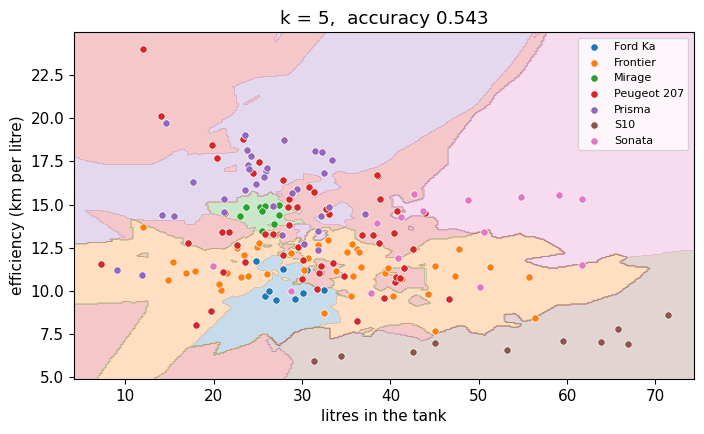

In [45]:
# ---------------------------------------------------------------------------
# CHANGE THIS AND RUN THE CELL AGAIN. Try 1, 3, 5, 9, 15, 25, 51.
k = 5
# ---------------------------------------------------------------------------

# StratifiedKFold is KFold that keeps the class proportions in every fold. With
# seven classes and as few as 9 rows in the smallest, that matters.
class_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

knn_class = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))

# For classification, scikit-learn's default score is the proportion CORRECT,
# so bigger is better. The error is one minus this.
accuracy = cross_val_score(knn_class, X_class, y_class, cv=class_folds).mean()

print("k = %d" % k)
print("  cross validated accuracy : %.3f" % accuracy)
print("  Ecv (proportion wrong)   : %.3f" % (1 - accuracy))
print("  guessing the commonest   : %.3f" % majority)

# Draw the regions the classifier assigns to each car.
knn_class.fit(X_class, y_class)

grid_x = np.linspace(X_class[:, 0].min() - 3, X_class[:, 0].max() + 3, 300)
grid_y = np.linspace(X_class[:, 1].min() - 1, X_class[:, 1].max() + 1, 300)
mesh_x, mesh_y = np.meshgrid(grid_x, grid_y)

grid_points = np.column_stack([mesh_x.ravel(), mesh_y.ravel()])
predicted = knn_class.predict(grid_points)

# Turn the predicted car names into numbers so they can be drawn as colours.
as_number = np.array([cars.index(name) for name in predicted]).reshape(mesh_x.shape)

plt.contourf(mesh_x, mesh_y, as_number, levels=np.arange(len(cars) + 1) - 0.5,
             colors=colours[:len(cars)], alpha=0.25)
for index, car in enumerate(cars):
    mask = y_class == car
    plt.scatter(X_class[mask, 0], X_class[mask, 1], s=28, color=colours[index],
                label=car, edgecolor="white", linewidth=0.5)

plt.xlabel("litres in the tank")
plt.ylabel("efficiency (km per litre)")
plt.title("k = %d,  accuracy %.3f" % (k, accuracy))
plt.legend(fontsize=8)
plt.show()

Run that cell at `k = 1` and at `k = 51` and compare the shapes of the coloured
regions.

At `k = 1` the map is a patchwork: little islands of colour around individual
observations, and a boundary that reacts to every single point. At `k = 51` the map
collapses to a couple of broad bands, because fifty-one neighbours reach right
across the picture and the commonest cars outvote everything else.

That is the bias-variance trade-off.

k =  1    accuracy = 0.514    Ecv = 0.486
k =  2    accuracy = 0.480    Ecv = 0.520
k =  3    accuracy = 0.514    Ecv = 0.486
k =  5    accuracy = 0.543    Ecv = 0.457
k =  7    accuracy = 0.521    Ecv = 0.479
k =  9    accuracy = 0.504    Ecv = 0.496
k = 15    accuracy = 0.486    Ecv = 0.514
k = 25    accuracy = 0.405    Ecv = 0.595
k = 40    accuracy = 0.405    Ecv = 0.595
k = 51    accuracy = 0.376    Ecv = 0.624

best accuracy at k = 5


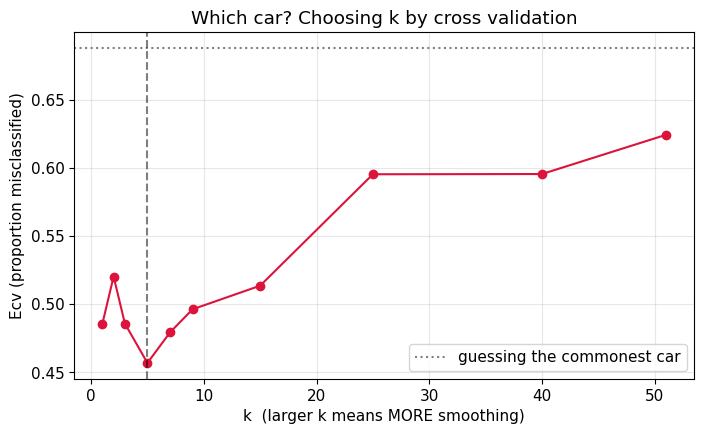

In [46]:
# All the values of k at once.

k_values_class = [1, 2, 3, 5, 7, 9, 15, 25, 40, 51]
accuracies = []

for k in k_values_class:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    accuracies.append(cross_val_score(model, X_class, y_class,
                                      cv=class_folds).mean())

for k, accuracy in zip(k_values_class, accuracies):
    print("k = %2d    accuracy = %.3f    Ecv = %.3f" % (k, accuracy, 1 - accuracy))

best_k_class = k_values_class[int(np.argmax(accuracies))]
print()
print("best accuracy at k = %d" % best_k_class)

plt.plot(k_values_class, 1 - np.array(accuracies), "o-", color="crimson")
plt.axhline(1 - majority, color="grey", linestyle=":",
            label="guessing the commonest car")
plt.axvline(best_k_class, color="black", linestyle="--", alpha=0.5)
plt.xlabel("k  (larger k means MORE smoothing)")
plt.ylabel("Ecv (proportion misclassified)")
plt.title("Which car? Choosing k by cross validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [47]:
# WHICH cars does it confuse? Fit at the chosen k and cross-tabulate.
from sklearn.model_selection import cross_val_predict

final_car_model = make_pipeline(StandardScaler(),
                                KNeighborsClassifier(n_neighbors=best_k_class))

# cross_val_predict gives each row a prediction made by a model that did NOT
# see that row, so the table below is honest about out-of-sample behaviour.
predicted = cross_val_predict(final_car_model, X_class, y_class, cv=class_folds)

table = pd.crosstab(pd.Series(y_class, name="actually"),
                    pd.Series(predicted, name="predicted"))
table

predicted,Ford Ka,Frontier,Mirage,Peugeot 207,Prisma,S10,Sonata
actually,,,,,,,
Ford Ka,5,2,0,2,0,0,0
Frontier,3,26,1,11,1,1,0
Mirage,0,1,8,0,0,0,0
Peugeot 207,3,16,4,22,7,0,2
Prisma,0,4,4,8,17,0,0
S10,0,0,0,0,0,10,0
Sonata,1,3,0,5,0,0,6


In [48]:
# Refit on all the training data, ready for Section 12.
final_car_model.fit(X_class, y_class)
print("Classifier refitted on all %d training rows, with k = %d."
      % (len(y_class), best_k_class))

Classifier refitted on all 173 training rows, with k = 5.


> ### Discuss
>
> **Q11.1** Look at the table. Which cars does the classifier confuse with each
> other, and which does it almost always get right? Does the pattern make practical
> sense? Compare it with the prediction you wrote down in Q9.3 last week.
>
> **Q11.2** The accuracy is somewhere around 0.5. Is that good? Compare it with
> guessing the commonest car, and with guessing uniformly at random among seven.
>
> **Q11.3** We used `litres` and `efficiency`. Why would adding `km_on_tank` as a
> third feature be a strange thing to do here? [*Hint*: what were you told in
> Section 1 about how `efficiency` is computed?]

## 12. Opening the test sample

Every decision is now made. We have chosen the polynomial degree, the number of
neighbours, the bandwidth, and the features, and every one of those choices came
from cross validation on the training data alone.

The test sample has taken no part in any of it. So now, once, we open it.

Before you run the next cell, **write down what you expect**. Will `Etest` be
better or worse than `Ecv`? Commit to an answer, then look.

In [49]:
# In Section 4 of Part A we wrote the test sample to a file and closed it.
# Now, and only now, we open that file again.

test_data = pd.read_csv("test_sample.csv")

print("test rows:", len(test_data))
print()
print(test_data["vehicle"].value_counts().to_string())

test rows: 44

vehicle
Peugeot 207    14
Frontier       11
Prisma          9
Sonata          4
Ford Ka         2
Mirage          2
S10             2


In [50]:
# ---- Problem 1: predicting efficiency --------------------------------------
# Only the test rows that have a driving condition can be used, since the model
# needs it as a feature.

test_reg = test_data[test_data["driving_condition"].notna()].reset_index(drop=True)
y_test_reg = test_reg["efficiency"].values

print("test rows usable for the regression:", len(y_test_reg))
print()

# Build the polynomial features for the test rows in EXACTLY the same way as for
# the training rows: the same dummy columns, in the same order, and the same
# powers of km_on_tank.
test_base = pd.concat([
    pd.get_dummies(test_reg["vehicle"], prefix="is", drop_first=True),
    pd.get_dummies(test_reg["driving_condition"], prefix="is", drop_first=True),
], axis=1).astype(float)

# .reindex(columns=...) forces the columns to match the training features
# exactly, inserting a column of zeros for any category that happens not to
# appear among the test rows. Without this the model would be handed its
# features in the wrong order.
test_base = test_base.reindex(columns=base_features.columns, fill_value=0.0)

test_poly = test_base.copy()
for power in range(1, best + 1):
    test_poly["km^%d" % power] = test_reg["km_on_tank"].values ** power

# The three sets of predictions.
predicted_poly = final_poly.predict(test_poly)
predicted_knn = knn_group(final_training_data, test_reg, best_k)
predicted_kernel = kernel_group(final_training_data, test_reg, best_sigma)

# Their errors.
Etest_poly = ((y_test_reg - predicted_poly) ** 2).mean()
Etest_knn = ((y_test_reg - predicted_knn) ** 2).mean()
Etest_kernel = ((y_test_reg - predicted_kernel) ** 2).mean()

# And the baseline, using the mean of the TRAINING data: predicting with the
# test mean would be using the test sample.
baseline_test = ((y_test_reg - y_reg.mean()) ** 2).mean()

print("PROBLEM 1: how efficient will this tank be?")
print("%-34s %10s %10s" % ("", "Ecv", "Etest"))
print("%-34s %10.3f %10.3f"
      % ("polynomial, degree %d" % best, min(Ecv_values), Etest_poly))
print("%-34s %10.3f %10.3f"
      % ("nearest neighbours, k = %d" % best_k, min(knn_Ecv), Etest_knn))
print("%-34s %10.3f %10.3f"
      % ("kernel, sigma = %d km" % best_sigma, min(kernel_Ecv), Etest_kernel))
print("%-34s %10.3f %10.3f"
      % ("baseline: predict the mean", baseline_error, baseline_test))

test rows usable for the regression: 26

PROBLEM 1: how efficient will this tank be?
                                          Ecv      Etest
polynomial, degree 1                    1.505      1.753
nearest neighbours, k = 3               1.352      2.303
kernel, sigma = 50 km                   1.200      2.163
baseline: predict the mean              6.176      8.686


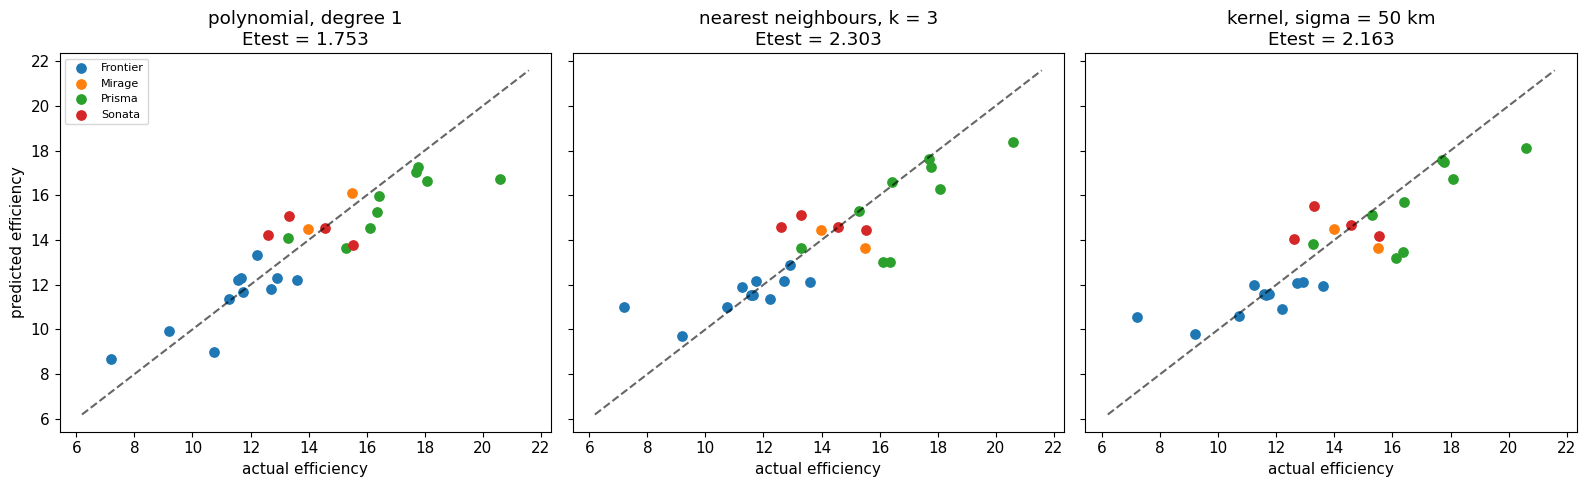

In [51]:
# Always look at the predictions, not only at the error.
#
# A "predicted against actual" plot puts the truth on the horizontal axis and
# the model's guess on the vertical one. A perfect model would put every point
# exactly on the diagonal line.

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

everything = [
    ("polynomial, degree %d" % best, predicted_poly, Etest_poly),
    ("nearest neighbours, k = %d" % best_k, predicted_knn, Etest_knn),
    ("kernel, sigma = %d km" % best_sigma, predicted_kernel, Etest_kernel),
]

# The range the diagonal has to span.
low = min(y_test_reg.min(), predicted_poly.min()) - 1
high = max(y_test_reg.max(), predicted_poly.max()) + 1

for ax, (name, predicted, error) in zip(axes, everything):

    # Colour each test tank by its car, so we can see who is hard to predict.
    for car in sorted(test_reg["vehicle"].unique()):
        chosen = (test_reg["vehicle"] == car).values
        ax.scatter(y_test_reg[chosen], predicted[chosen], s=45, label=car)

    # The perfect-prediction line.
    ax.plot([low, high], [low, high], color="black", linestyle="--", alpha=0.6)

    ax.set_title("%s\nEtest = %.3f" % (name, error))
    ax.set_xlabel("actual efficiency")

axes[0].set_ylabel("predicted efficiency")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [52]:
# ---- Problem 2: which car? -------------------------------------------------

# The same two features, taken from the test rows.
X_test_class = test_data[["litres", "efficiency"]].values
y_test_class = test_data["vehicle"].values

# Compare prediction with truth; == gives True/False, and .mean() of that is
# the proportion correct.
test_accuracy = (final_car_model.predict(X_test_class) == y_test_class).mean()

print("PROBLEM 2: which car is this tank from?")
print("  cross validated accuracy : %.3f" % max(accuracies))
print("  accuracy on the test set : %.3f" % test_accuracy)
print("  guessing the commonest   : %.3f" % majority)
print()
print("  test sample size: %d rows, so the error bar on that number is wide."
      % len(y_test_class))
print("  With 44 observations, a difference of a few percent is noise.")

PROBLEM 2: which car is this tank from?
  cross validated accuracy : 0.543
  accuracy on the test set : 0.500
  guessing the commonest   : 0.312

  test sample size: 44 rows, so the error bar on that number is wide.
  With 44 observations, a difference of a few percent is noise.


> ### Discuss
>
> **Q12.1** Compare `Etest` with `Ecv` for each model. Are they close? Is `Etest`
> better or worse, and did you predict the direction correctly?
>
> **Q12.2** Now look at the *order* of the three models. Cross validation ranked
> them kernel, then nearest neighbours, then polynomial. Does the test sample agree?
>
> **Q12.3** Someone will want to explain the gap. Two candidate explanations:
> (i) `Ecv` was optimistically biased because we chose the model by it; (ii) the
> test sample is small, so `Etest` is noisy. How would you tell these apart? Can
> you, with the data you have?
>
> **Q12.4** You now have a number. Suppose you wanted to do better. You have ideas:
> a different set of features, a random forest, a longer list of bandwidths. What
> are you allowed to do, and what happens to the honesty of the number you just
> computed?

## 13. Summary of weeks 5 and 6 tutorials

Start to finish, this is the whole pipeline:

1. **Understand the problem before the data.** What the columns mean, how they were
   collected, which ones are derived from others, which ones are not comparable.
2. **Lock away a test sample, immediately.** Before the first plot.
3. **Look at the data.** Distributions, groups, and distributions within groups.
   Most of what we learned about these cars, we learned here.
4. **Get the features into a usable form.** Categorical variables become `k - 1`
   yes/no columns, never a single number pretending the categories are ordered.
5. **Build candidate models of increasing complexity.** Polynomial degree, number
   of neighbours, bandwidth.
6. **Choose the complexity by cross validation, never by `Ein`.**
7. **Refit the chosen model on all the training data.**
8. **Open the test sample once**, report the number, and stop.

That sequence does not depend on the models being the ones from Lecture 4. Swap in
a neural network and steps 1 to 8 are unchanged. It is the pipeline, not the model,
that makes the number at the end mean something.

---

## 14. (Optional) Was this tank a highway trip?

This section is optional, and it sits at the end so that it does not interrupt the
main pipeline. The code is written out; run it and discuss.

**The question.** Can we recover the driving condition?

We simplify to a binary question: did this tank involve any highway driving?
`Highway` and `Mixed` become yes, `City` becomes no. The features are the car, the
distance, and the efficiency.

Everything below reuses `reg`, `class_folds` and `test_reg`, which were built
earlier in the notebook, so run the sections above first.

In [53]:
# The outcome: yes if the tank involved any highway driving.
#
# np.where(condition, a, b) builds an array that holds a where the condition is
# True and b where it is False.
y_trip = np.where(reg["driving_condition"] == "City", "no", "yes")

# The features: the car (one-hot, as always), the distance, and the efficiency.
X_trip = pd.get_dummies(reg["vehicle"], prefix="is", drop_first=True).astype(float)
X_trip["km_on_tank"] = reg["km_on_tank"].values
X_trip["efficiency"] = reg["efficiency"].values

# The baseline: always answer whichever is commoner.
majority_trip = pd.Series(y_trip).value_counts(normalize=True).max()

print(pd.Series(y_trip).value_counts().to_string())
print()
print("always guessing the commonest answer: %.3f" % majority_trip)

yes    64
no     28

always guessing the commonest answer: 0.696


In [54]:
# Three of the models from Lecture 4, on the same problem.

# 1. Logistic regression: it models the probability of the class and predicts
#    whichever is more likely. It is a LINEAR classifier - the same hypothesis
#    set as the perceptron from Lecture 1.
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
logistic_accuracy = cross_val_score(logistic, X_trip, y_trip,
                                    cv=class_folds).mean()
print("logistic regression      accuracy = %.3f" % logistic_accuracy)
print()

# 2. k nearest neighbours, for comparison.
for k in [1, 3, 5, 9, 15, 31]:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    print("kNN, k = %2d              accuracy = %.3f"
          % (k, cross_val_score(model, X_trip, y_trip, cv=class_folds).mean()))
print()

# 3. A decision tree (CART), also from Lecture 4. It asks a series of yes/no
#    questions of the form "is this feature below this threshold?", and its
#    complexity knob is how deep it is allowed to go. max_depth=None means no
#    limit, which lets it grow until every leaf is pure.
tree_depths = [1, 2, 3, 4, 5, 7, None]
tree_accuracies = []

for depth in tree_depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0)
    accuracy = cross_val_score(tree, X_trip, y_trip, cv=class_folds).mean()
    tree_accuracies.append(accuracy)
    print("decision tree, depth %-4s accuracy = %.3f" % (depth, accuracy))

# The best depth, and the tree refitted at it.
best_depth = tree_depths[int(np.argmax(tree_accuracies))]
print()
print("best tree depth:", best_depth)

logistic regression      accuracy = 0.825

kNN, k =  1              accuracy = 0.868
kNN, k =  3              accuracy = 0.846
kNN, k =  5              accuracy = 0.792
kNN, k =  9              accuracy = 0.793
kNN, k = 15              accuracy = 0.696
kNN, k = 31              accuracy = 0.696

decision tree, depth 1    accuracy = 0.728
decision tree, depth 2    accuracy = 0.836
decision tree, depth 3    accuracy = 0.792
decision tree, depth 4    accuracy = 0.825
decision tree, depth 5    accuracy = 0.781
decision tree, depth 7    accuracy = 0.804
decision tree, depth None accuracy = 0.803

best tree depth: 2


In [55]:
# How much does knowing the car matter? Drop the car columns and refit.

without_car = X_trip[["km_on_tank", "efficiency"]]

with_car_accuracy = logistic_accuracy
without_car_accuracy = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    without_car, y_trip, cv=class_folds).mean()

print("logistic regression WITH the car    : %.3f" % with_car_accuracy)
print("logistic regression WITHOUT the car : %.3f" % without_car_accuracy)
print("guessing the commonest answer       : %.3f" % majority_trip)

logistic regression WITH the car    : 0.825
logistic regression WITHOUT the car : 0.684
guessing the commonest answer       : 0.696


That last comparison is the payoff of Section 7 and of the whole encoding
discussion. Removing the car columns does not merely cost accuracy, it takes the
classifier all the way back past the point of usefulness. Without knowing the car
it scores slightly **worse** than a rule that ignores the data entirely and always
answers "yes".

The reason is exactly what we found in Section 6 last week. Efficiency on its own
does not tell you how a tank was driven, because a thirsty car on the highway and
an economical car in the city look the same. Once the model knows which car it is,
efficiency becomes informative, because now it is being compared against the right
reference.

The plots below show it directly.

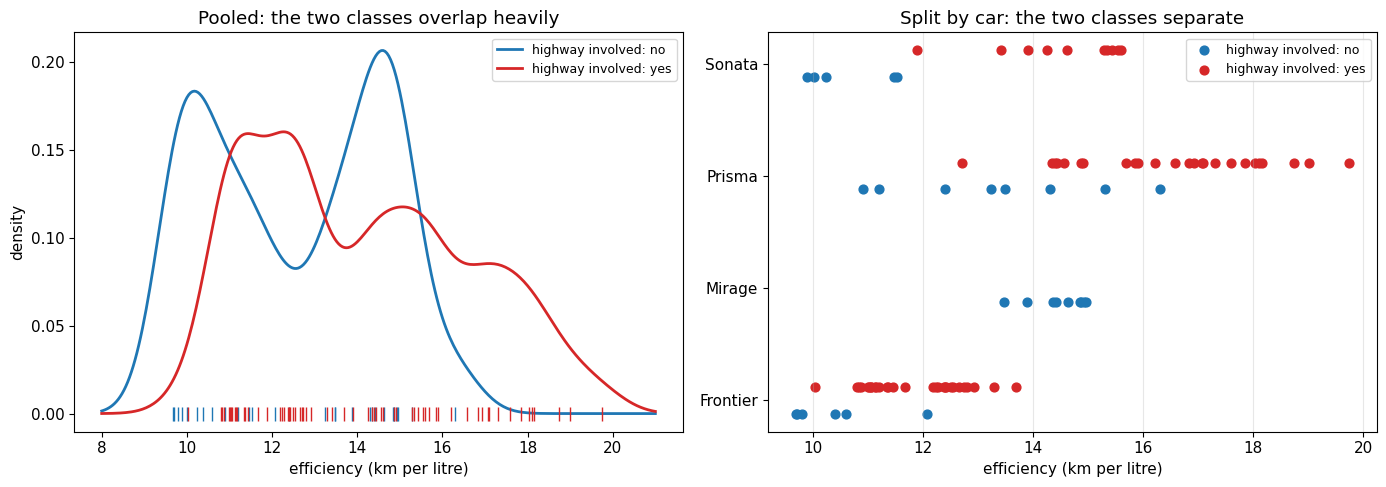

In [56]:
# Why knowing the car matters, in two pictures.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- left: efficiency alone, which is what the model sees WITHOUT the car ----
ax = axes[0]
for answer, colour in [("no", "tab:blue"), ("yes", "tab:red")]:

    # y_trip is a numpy array, so we index reg with it directly.
    values = reg["efficiency"].values[y_trip == answer]

    kde = KernelDensity(bandwidth=0.6, kernel="gaussian")
    kde.fit(values.reshape(-1, 1))

    grid = np.linspace(8, 21, 300).reshape(-1, 1)
    ax.plot(grid, np.exp(kde.score_samples(grid)), color=colour, linewidth=2,
            label="highway involved: %s" % answer)
    ax.plot(values, np.full_like(values, 0), "|", color=colour, markersize=10)

ax.set_xlabel("efficiency (km per litre)")
ax.set_ylabel("density")
ax.set_title("Pooled: the two classes overlap heavily")
ax.legend(fontsize=9)

# ---- right: the same thing, but one row per car ----------------------------
ax = axes[1]
cars_trip = sorted(reg["vehicle"].unique())

for row_position, car in enumerate(cars_trip):
    for answer, colour, offset in [("no", "tab:blue", -0.12),
                                   ("yes", "tab:red", 0.12)]:

        # Tanks of this car with this answer. The & means "and".
        chosen = (reg["vehicle"].values == car) & (y_trip == answer)
        values = reg["efficiency"].values[chosen]

        if len(values) == 0:
            continue

        # Draw them as a horizontal strip, one strip per car.
        ax.scatter(values, np.full_like(values, row_position + offset), s=40,
                   color=colour,
                   label="highway involved: %s" % answer if row_position == 0 else None)

ax.set_yticks(range(len(cars_trip)))
ax.set_yticklabels(cars_trip)
ax.set_xlabel("efficiency (km per litre)")
ax.set_title("Split by car: the two classes separate")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

On the left, the two classes are almost the same distribution: that is the
information a model has when it does not know which car it is looking at, and it
is not much.

On the right, the same tanks split car by car. Within every single car the red
points (highway involved) sit mainly to the right of the blue ones (city only). The
signal was there all along; pooling the cars destroyed it.

This is the same lesson as Section 6 of Part A: **a feature can be useless on its own and highly informative once
you condition on the right thing.**

> ### Discuss
>
> **Q14.1** Logistic regression, a *linear* classifier, gets within a few points of
> the best kNN here. What does that suggest about the shape of the boundary between
> highway tanks and city tanks, once the car is known? And kNN's best score is at
> `k = 1`. Given that a 1-nearest-neighbour rule reproduces its training data
> exactly, how much should that impress you?
>
> **Q14.2** We could not build this model for the Ford Ka, the S10 or the Peugeot,
> because they never recorded a driving condition. Yet those are precisely the cars
> whose missing labels we would most like to fill in. Explain the difficulty.

### The test sample, for this optional problem

The same rule applies here as everywhere else: this is the only
time these rows are used, and every choice above was made without
them.

In [57]:
# ---- Problem 3: was this tank a highway trip? ------------------------------

# The same features as earlier in this section, built from the test rows.
X_test_trip = pd.get_dummies(test_reg["vehicle"], prefix="is",
                             drop_first=True).astype(float)
X_test_trip = X_test_trip.reindex(columns=X_trip.columns, fill_value=0.0)
X_test_trip["km_on_tank"] = test_reg["km_on_tank"].values
X_test_trip["efficiency"] = test_reg["efficiency"].values

# The truth for those rows.
y_test_trip = np.where(test_reg["driving_condition"] == "City", "no", "yes")

# Refit the two models on all the training rows, then predict the test rows.
final_logistic = make_pipeline(StandardScaler(),
                               LogisticRegression(max_iter=5000))
final_logistic.fit(X_trip, y_trip)

final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=0)
final_tree.fit(X_trip, y_trip)

logistic_test = (final_logistic.predict(X_test_trip) == y_test_trip).mean()
tree_test = (final_tree.predict(X_test_trip) == y_test_trip).mean()

print("PROBLEM 3: was this tank a highway trip?")
print("%-34s %10s %10s" % ("", "Ecv", "Etest"))
print("%-34s %10.3f %10.3f"
      % ("logistic regression", logistic_accuracy, logistic_test))
print("%-34s %10.3f %10.3f"
      % ("decision tree, depth %s" % best_depth, max(tree_accuracies), tree_test))
print("%-34s %10.3f %10.3f"
      % ("guessing the commonest answer", majority_trip,
         (y_test_trip == "yes").mean()))

PROBLEM 3: was this tank a highway trip?
                                          Ecv      Etest
logistic regression                     0.825      0.731
decision tree, depth 2                  0.836      0.769
guessing the commonest answer           0.696      0.692
